#  Plots Summaries for Variables Across European Cities

This notebook provides a comprehensive visual analysis of key variables across various European cities.

The primary objective of this section is to generate and present **clear, comparative plots** for each significant variable in the dataset. These visualizations allow for a quick and intuitive understanding of the **distribution, range, and comparative performance** of the variable values among all included cities in Europe.



## Load libraries

Here we load the required libraries to execute the notebook. Note that specific code from dedicated scripts (`utils.py`, `urban_areas.py`, ...) is also loaded here.

In [49]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
!echo $CONDA_DEFAULT_ENV

jsc


In [51]:
import os
import sys
import calendar
import math
import itertools
import random

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.colors import BoundaryNorm
from matplotlib.patches import Polygon

import geopandas as gpd
from shapely.geometry import Point
import regionmask
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Custom/Internal Modules 
from urclimask.GHCNd_stations import get_valid_timeseries, inside_city
from urclimask.UHI_analysis import UrbanIsland
from urclimask.urban_areas import UrbanVicinity
from urclimask.utils import load_ucdb_city, traverseDir

# Internal Tools
from tools import (
    check_equal_period,
    fix_360_longitudes,
    open_datasets,
    standardize_unit,
)

In [52]:
save_results_path = os.path.abspath(
    os.path.join(os.getcwd(), "..", "intermediate-results")
)
save_figure_path = os.path.abspath(os.path.join(os.getcwd(), "..", "plots"))
save_figure_dataset = os.path.abspath(os.path.join(os.getcwd(), "..", "datasets"))

In [70]:
city = "Paris" 
variable = "tasmax"  
period = slice(1991, 2020)
rcm_names = [
    'ALARO1-SFX_v1-r1', 'CCLM6-0-1-URB_v1-r1', 'HCLIM43-ALADIN_v1-r1',
    'ICON-CLM-202407-1-1_v1-r1', 'RACMO23E_v1-r1',
    'REMO2020-2-2-MR2_v1-r1', 'REMO2020-2-2-TEB_v1-r1',
    'REMO2020-2-2_v1-r1', 'ROAM-NBS_v1-r1', 'RegCM5-0_v1-r1'
]

## Annual cycle

In [71]:
csv_path = "eurocordex_models_urban.csv"

# Read CSV without comment="#" so color fields starting with '#' are kept
models_df = pd.read_csv(csv_path, sep=",", engine="python", dtype=str)

# Strip whitespace from column names (defensive)
models_df.columns = [c.strip() for c in models_df.columns]

# --- Check that all required columns exist (now includes 'urban') ---
required_cols = {"model", "mip_era", "color", "urban"}
if not required_cols.issubset(set(models_df.columns)):
    raise RuntimeError(
        f"Missing columns in {csv_path}. Required: {required_cols}. "
        f"Found: {models_df.columns.tolist()}"
    )

# --- Filter only CMIP6 models ---
models_cmip6 = models_df[models_df["mip_era"].str.strip() == "CMIP6"].copy()

# --- Clean color format (ensure all start with "#") and handle NaNs ---
def clean_color(c):
    if pd.isna(c):
        return None
    s = str(c).strip()
    if not s:
        return None
    return s if s.startswith("#") else "#" + s

models_cmip6["color"] = models_cmip6["color"].apply(clean_color)

# --- Match models to your RCM names (base name before version) ---
rcm_base_names = [name.split("_v")[0] for name in rcm_names]
models_plot = models_cmip6[models_cmip6["model"].isin(rcm_base_names)].copy()

# --- Create color and style mapping dicts ---
model_colors = {}
model_styles = {}  # new: line/marker styles

for rcm_name in rcm_names:
    base = rcm_name.split("_v")[0]
    row = models_plot.loc[models_plot["model"] == base]
    
    if not row.empty:
        color = row["color"].values[0]
        urban = row["urban"].values[0].strip() if "urban" in row.columns else ""
        
        # assign color
        model_colors[rcm_name] = color if pd.notna(color) else "#999999"
        
        # assign style based on urban column
        if urban == "UCM":
            model_styles[rcm_name] = {"linestyle": "--", "marker": "o"}  # dashed + dots
        else:
            model_styles[rcm_name] = {"linestyle": "-", "marker": None}   # normal line
    else:
        model_colors[rcm_name] = "#999999"
        model_styles[rcm_name] = {"linestyle": "-", "marker": None}

Figure saved to: /mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/urban-evaluation/plots/summaries/CMIP6_Paris_Annual_cycle_tasmax_1991-2020.png


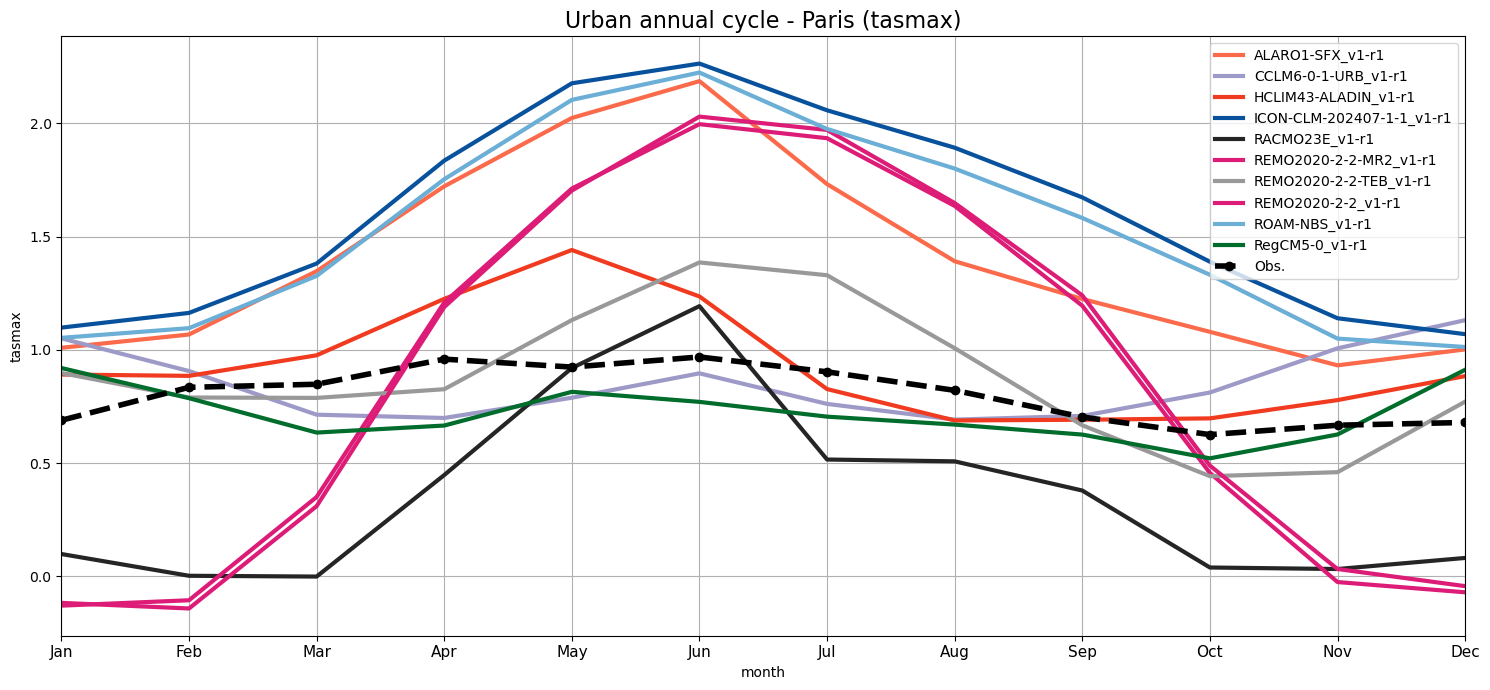

In [72]:


# Base path for saving figures
save_summary_path = os.path.join(save_figure_path, "summaries")
os.makedirs(save_summary_path, exist_ok=True)

# === PLOT INITIALIZATION ===
fig, ax = plt.subplots(figsize=(15, 7))

for rcm_name in rcm_names:
    # File paths
    output_nc_path = f"{save_figure_dataset}/Annual_cycle/CMIP6_{city}_Annual_cycle_{variable}_{rcm_name}_{period.start}-{period.stop}.nc"
    output_urmask_nc_path = f"{save_figure_dataset}/urmask/CMIP6_{city}_urmask_{rcm_name}.nc"

    # Skip if files do not exist
    if not (os.path.exists(output_nc_path) ):
        print(f"Skipping {rcm_name}: missing .nc or urmask file.")
        continue

    try:
        # Open datasets
        ds_anomaly = xr.open_dataset(output_nc_path)[variable]
        urmask = xr.open_dataset(output_urmask_nc_path)

        # Align coordinates (if needed)
        ds_anomaly = ds_anomaly.assign_coords(
            {urmask.cf['X'].name: urmask[urmask.cf['X'].name],
             urmask.cf['Y'].name: urmask[urmask.cf['Y'].name]}
        )

        # Create urban mask
        is_urban = urmask['urmask'] == 1
        urban_anomaly = ds_anomaly.where(is_urban)

        # Compute spatial mean
        urban_mean = urban_anomaly.mean(
            dim=[ds_anomaly.cf['Y'].name, ds_anomaly.cf['X'].name]
        ).compute()

        # Plot with fixed color
        urban_mean.plot(ax=ax, color=model_colors[rcm_name], linewidth=3, label=rcm_name)

    except Exception as e:
        print(f"Error processing {rcm_name}: {e}")
        continue

# === OBSERVATIONS (CSV) ===
output_obs_csv_path = f"{save_figure_dataset}/Annual_cycle/observations/CMIP6_{city}_Annual_cycle_{variable}_OBS_{period.start}-{period.stop}.csv"
if os.path.exists(output_obs_csv_path):
    obs_df = pd.read_csv(output_obs_csv_path)
    if obs_df.index[0] == 0:
        obs_df.index += 1
    ax.plot(obs_df.index, obs_df['urban_mean'], color='k', linestyle='--', marker='o',
            linewidth=4, label='Obs.', zorder=2000)
else:
    print(f"Observation file not found: {output_obs_csv_path}")

# === AXIS SETTINGS ===
ax.set_xticks(range(1, 13))
ax.set_xticklabels([calendar.month_abbr[i] for i in range(1, 13)], fontsize=11)
ax.set_xlim(1, 12)

# === FIGURE STYLE ===
ax.set_title(f"Urban annual cycle - {city} ({variable})", fontsize=16)
ax.set_ylabel(variable)
ax.legend()
ax.grid(True)
plt.tight_layout()

# === SAVE FIGURE ===
output_png_path = os.path.join(save_summary_path,
                               f"CMIP6_{city}_Annual_cycle_{variable}_{period.start}-{period.stop}.png")
plt.savefig(output_png_path, dpi=300)
print(f"Figure saved to: {output_png_path}")


In [73]:
import yaml

# Cargar el archivo YAML
with open("cities.yaml", "r") as f:
    cities = yaml.safe_load(f)

Figure saved to: /mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/urban-evaluation/plots/summaries/CMIP6_AllCities_tasmax_1991-2020.png
Figure saved at: /mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/urban-evaluation/plots/summaries/CMIP6_AllCities_tasmax_1991-2020.pdf


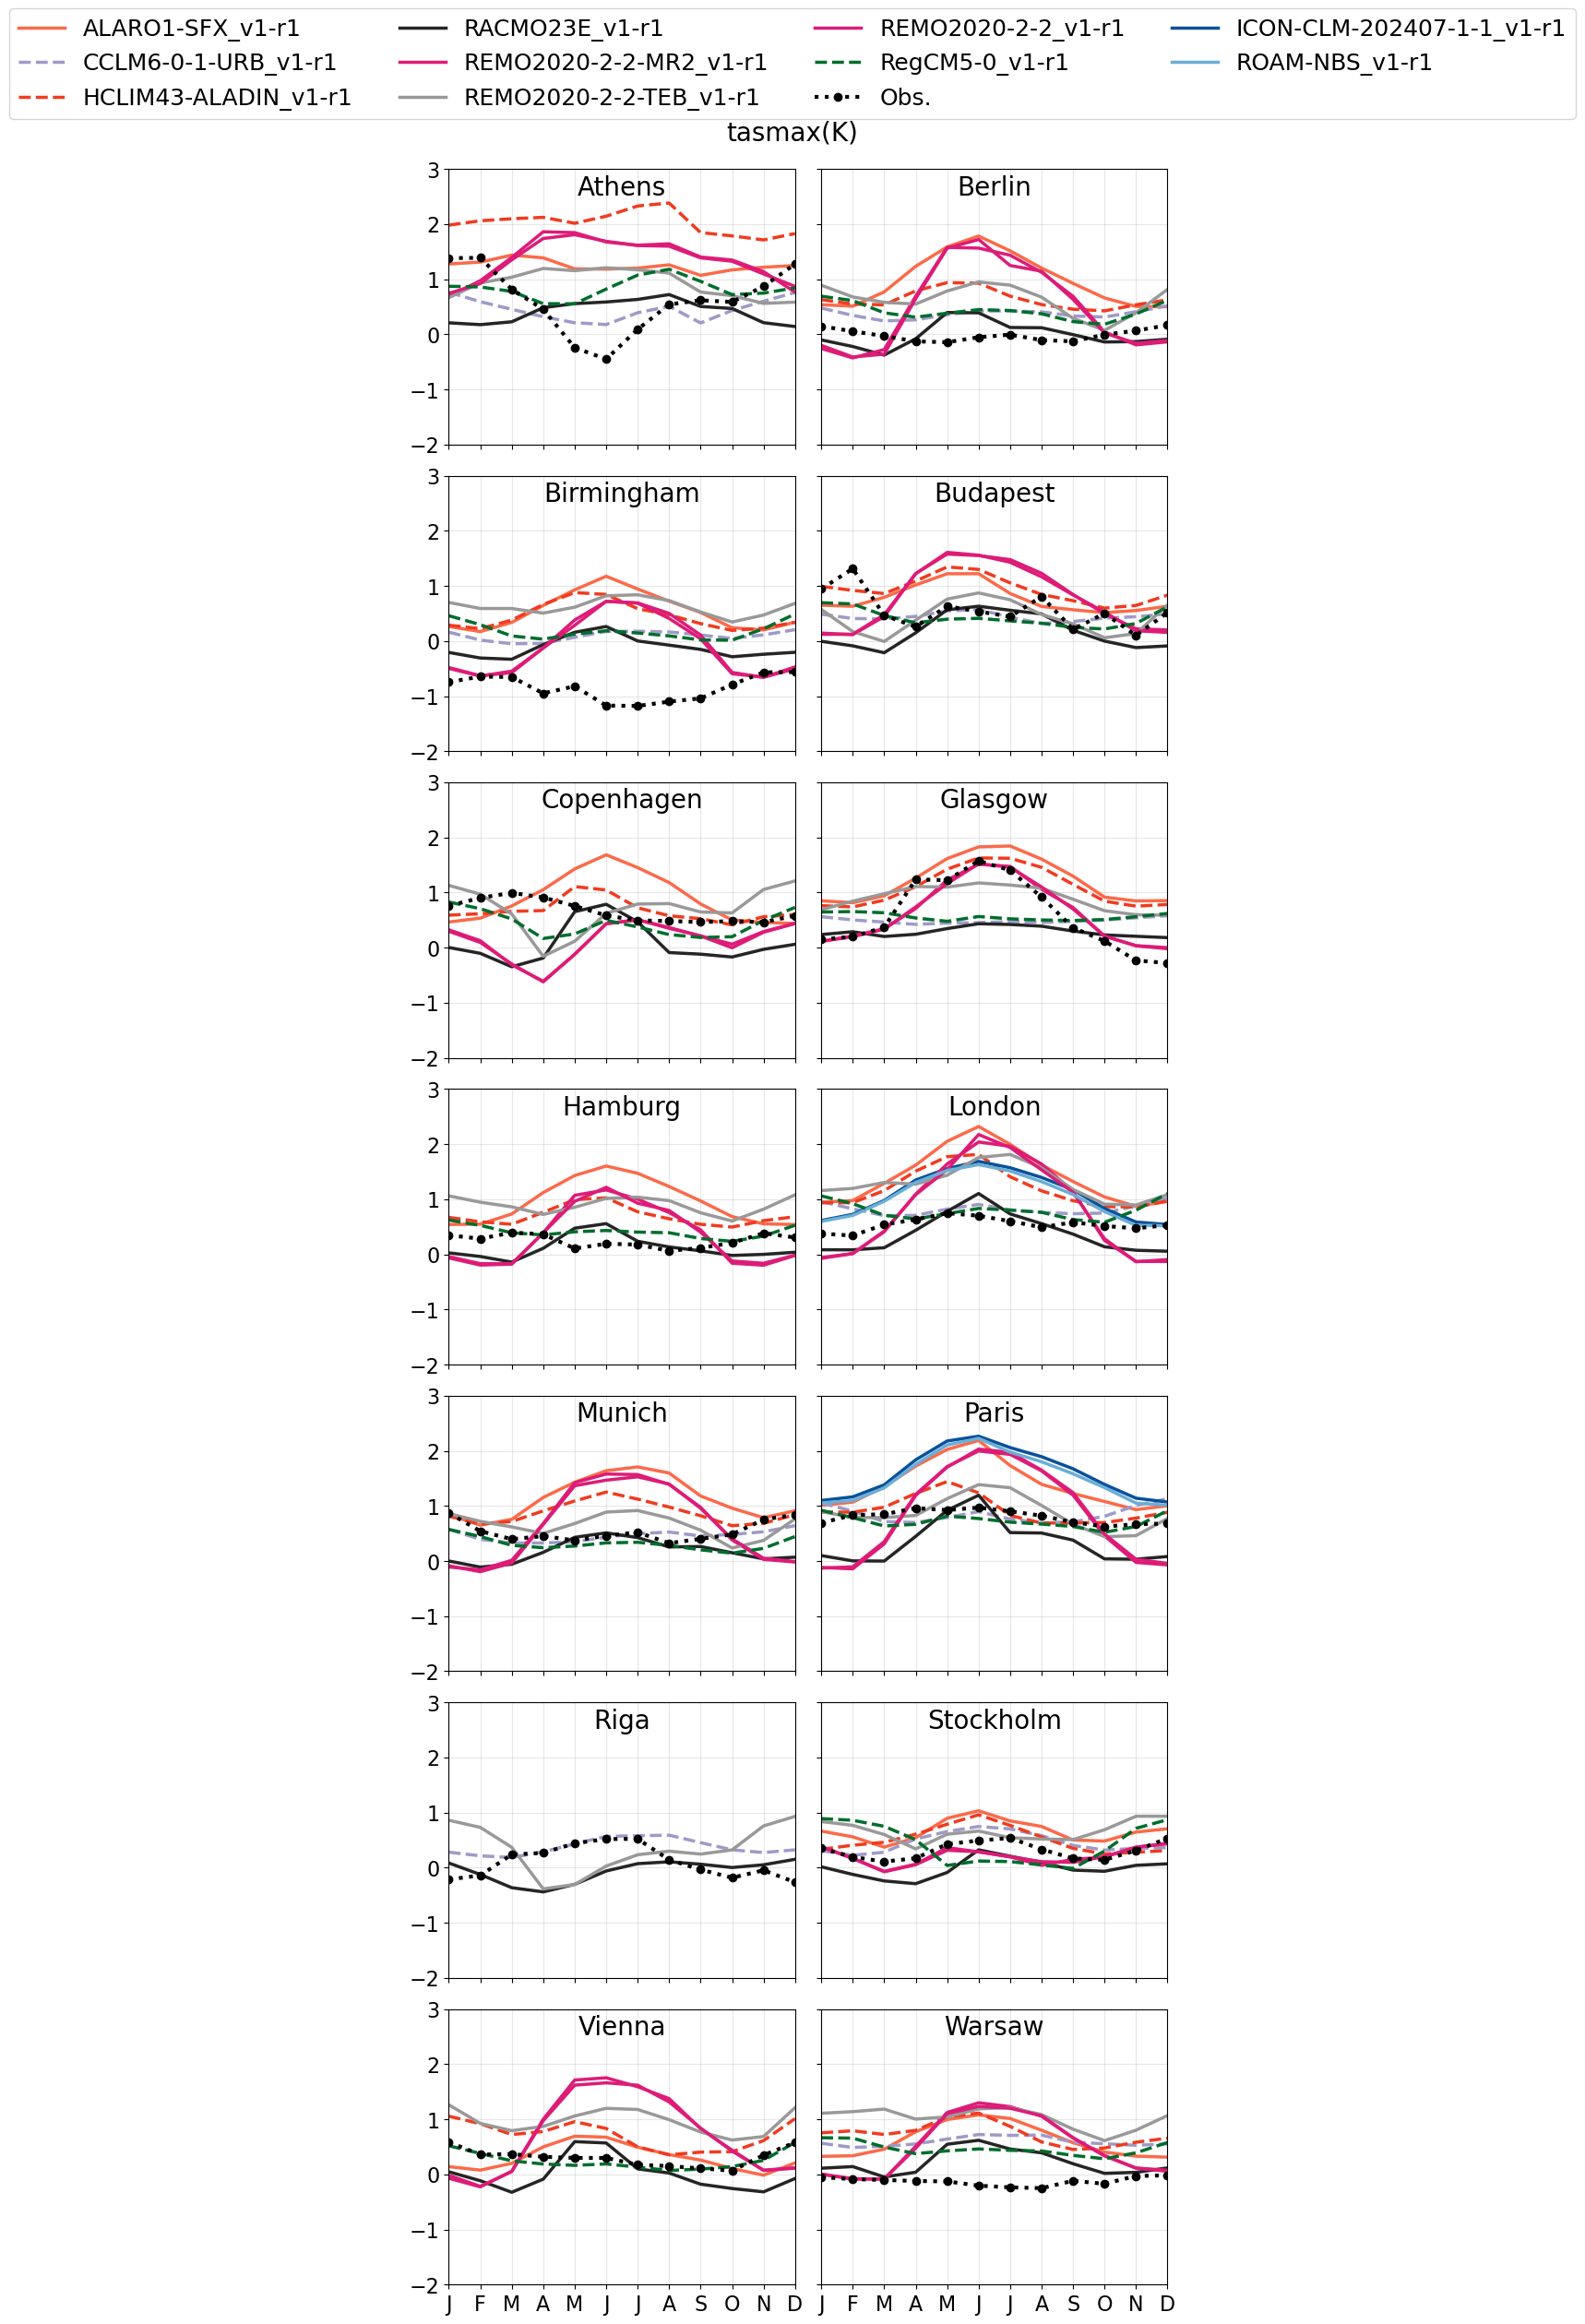

In [74]:
# --- Colors ---
obs_color = "k"  # black for observations

# --- Output directory ---
save_summary_path = os.path.join(save_figure_path, "summaries")
os.makedirs(save_summary_path, exist_ok=True)

# --- Layout ---
ncols = 2
nplots = len([c for c in cities if c != "default"])
nrows = math.ceil(nplots / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4.3 * ncols, 3.8 * nrows),  
    sharex=True
)

axes = axes.flatten()

# --- Main loop ---
plot_idx = 0
for city in cities:
    if city == "default":
        continue

    ax = axes[plot_idx]
    plot_idx += 1
    plotted_any = False

    for rcm_name in rcm_names:
        output_nc_path = f"{save_figure_dataset}/Annual_cycle/CMIP6_{city}_Annual_cycle_{variable}_{rcm_name}_{period.start}-{period.stop}.nc"
        output_urmask_nc_path = f"{save_figure_dataset}/urmask/CMIP6_{city}_urmask_{rcm_name}.nc"

        if not (os.path.exists(output_nc_path) and os.path.exists(output_urmask_nc_path)):
            continue

        try:
            ds_anomaly = xr.open_dataset(output_nc_path)[variable]
            urmask = xr.open_dataset(output_urmask_nc_path)

            ds_anomaly = ds_anomaly.assign_coords({
                urmask.cf['X'].name: urmask[urmask.cf['X'].name],
                urmask.cf['Y'].name: urmask[urmask.cf['Y'].name]
            })

            is_urban = urmask['urmask'] == 1
            urban_anomaly = ds_anomaly.where(is_urban)

            urban_mean = urban_anomaly.mean(
                dim=[ds_anomaly.cf['Y'].name, ds_anomaly.cf['X'].name]
            ).compute()

            urban_mean.plot(
                ax=ax,
                color=model_colors[rcm_name],
                linestyle=model_styles[rcm_name]["linestyle"],
                linewidth=2.5,
                label=rcm_name
            )
            plotted_any = True

        except Exception as e:
            print(f"Error in {city} - {rcm_name}: {e}")
            continue

    # --- Observations ---
    output_obs_csv_path = f"{save_figure_dataset}/Annual_cycle/observations/CMIP6_{city}_Annual_cycle_{variable}_OBS_{period.start}-{period.stop}.csv"

    if os.path.exists(output_obs_csv_path):
        obs_df = pd.read_csv(output_obs_csv_path)
        if "month" in obs_df.columns:
            obs_df.set_index("month", inplace=True)
        elif obs_df.index[0] == 0:
            obs_df.index += 1

        if "urban_mean" in obs_df.columns:
            ax.plot(
                obs_df.index,
                obs_df["urban_mean"],
                color=obs_color,
                linestyle=":",
                marker="o",
                linewidth=3,
                label="Obs.",
                zorder=2000,
            )
            plotted_any = True
        else:
            print(f"Missing 'urban_mean' column in {output_obs_csv_path}")
    else:
        print(f"Missing observation file for {city}")

    # --- Formatting ---
    ax.set_title("", fontsize=16, pad=10)
    # Remove external title and place city name inside the plot
    ax.text(
        0.5, 0.98, city,                   # centered horizontally, slightly below the top
        transform=ax.transAxes,            # use axes coordinates (0–1)
        fontsize=20,
        ha='center',
        va='top'
    )
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(1, 13))
    ax.set_xlim(1, 12)
    ax.set_xticklabels([calendar.month_abbr[m][0] for m in range(1, 13)], fontsize=15)
    ax.set_xlabel("")
    ax.set_ylabel("")
    if variable == 'hurs':
        ax.set_ylim(-15, 10)
    if variable == 'sfcWind':
        ax.set_ylim(-3, 1)
    if variable == 'tasmin':
        ax.set_ylim(-1, 5)
    if variable == 'tasmax':
        ax.set_ylim(-2, 3)
    ax.tick_params(axis='both', which='major', labelsize=16)


    # Hide y-axis label for all but first column
    if plot_idx % ncols != 1:
        ax.set_yticklabels([])

    if not plotted_any:
        ax.set_facecolor("#f5f5f5")

# --- Remove empty axes ---
for j in range(plot_idx, len(axes)):
    fig.delaxes(axes[j])

# --- Legend ---
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# Remove duplicates while preserving order
unique = dict(zip(labels, handles))
handles, labels = list(unique.values()), list(unique.keys())

plt.tight_layout()
plt.subplots_adjust(top=0.88)

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    fontsize=18,
    bbox_to_anchor=(0.5, 0.95)
)

# --- Title and Save ---
units = {
    "tasmin": "K",
    "tasmax": "K",
    "pr": "% (mm/day)",
    "sfcWind": "m s⁻¹",
    "hurs": "%"
}.get(variable, "")

fig.suptitle(
    f"{variable}({units})",
    fontsize=20,
    y=0.9
)

output_png_path = os.path.join(
    save_summary_path,
    f"CMIP6_AllCities_{variable}_{period.start}-{period.stop}.png"
)

plt.savefig(output_png_path, dpi=300, bbox_inches="tight")
print(f"Figure saved to: {output_png_path}")

# Save figure
output_pdf = os.path.join(
    save_summary_path,
    f"CMIP6_AllCities_{variable}_{period.start}-{period.stop}.pdf"
)
plt.savefig(output_pdf, format="pdf", bbox_inches="tight")
print(f"Figure saved at: {output_pdf}")

## Heatmap

In [10]:
import geopandas as gpd

root_aux_data = "/mnt/CORDEX_CMIP6_tmp/aux_data/"
ucdb_path = f"{root_aux_data}GHS_FUA_UCD/GHS_UCDB_GLOBE_R2024A.gpkg"

# Load UCDB layers
gdf_centroids = gpd.read_file(ucdb_path, layer="UC_centroids")
gdf_char = gpd.read_file(ucdb_path, layer="GHS_UCDB_THEME_GENERAL_CHARACTERISTICS_GLOBE_R2024A")

# Clean column names
gdf_centroids.columns = gdf_centroids.columns.str.strip().str.replace("﻿", "", regex=True)
gdf_char.columns = gdf_char.columns.str.strip().str.replace("﻿", "", regex=True)

# Reproject to WGS84
gdf_centroids = gdf_centroids.to_crs(epsg=4326)

# Merge centroid geometry with characteristics
gdf_merged = gdf_char.merge(
    gdf_centroids[["ID_UC_G0", "geometry"]],
    on="ID_UC_G0",
    suffixes=("_char", "_centroid")
)

# Set the geometry to the centroid geometry
gdf_merged = gdf_merged.set_geometry("geometry_centroid")

# Extract lon/lat for filtering
lon_tmp = gdf_merged.geometry.x
lat_tmp = gdf_merged.geometry.y

# Filter cities by area and Europe bounding box
gdf_filtered = gdf_merged[gdf_merged["GC_UCA_KM2_2025"] >= 12.5 * 12.5].copy()
gdf_europe = gdf_filtered[
    (lat_tmp >= 34) & (lat_tmp <= 72) &
    (lon_tmp >= -25) & (lon_tmp <= 45)
].copy()

print(f"Filtered European cities (≥144 km²): {len(gdf_europe)}")


# ----------------------------------------------------------------------
# PREPARE CITY-COUNTRY LIST
# ----------------------------------------------------------------------
def clean_string(s):
    if isinstance(s, str):
        return s.strip().replace("\ufeff", "")
    return s

gdf_europe["GC_UCN_MAI_2025"] = gdf_europe["GC_UCN_MAI_2025"].apply(clean_string)
gdf_europe["GC_CNT_GAD_2025"] = gdf_europe["GC_CNT_GAD_2025"].apply(clean_string)
city_country_list = list(zip(gdf_europe["GC_UCN_MAI_2025"], gdf_europe["GC_CNT_GAD_2025"]))

Filtered European cities (≥144 km²): 95


/home/yquintana/.conda/envs/jsc/lib/python3.10/site-packages/geopandas/geodataframe.py:1896: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)


In [11]:
# SORT CITIES BY URBAN AREA AND CAPITALIZE NAMES
# Sort by area (descending: largest first)
gdf_sorted = gdf_europe.sort_values(by="GC_UCA_KM2_2025", ascending=False).reset_index(drop=True)

# Capitalize city names
gdf_sorted["GC_UCN_MAI_2025"] = gdf_sorted["GC_UCN_MAI_2025"].str.title()  # "essen" -> "Essen"

# Create ordered city and country lists
cities = gdf_sorted["GC_UCN_MAI_2025"].tolist()
countries = gdf_sorted["GC_CNT_GAD_2025"].tolist()

# Optional: combine into tuples if needed later
city_country_list = list(zip(cities, countries))

print(f"European cities sorted by area: {len(cities)} total")
print("Top 10 largest cities by area:")
print(gdf_sorted[["GC_UCN_MAI_2025", "GC_UCA_KM2_2025"]].head(10))

European cities sorted by area: 95 total
Top 10 largest cities by area:
  GC_UCN_MAI_2025  GC_UCA_KM2_2025
0          London             1649
1          Moscow             1545
2           Paris             1421
3        Istanbul             1269
4           Essen              880
5           Milan              785
6      Manchester              751
7      Birmingham              685
8          Berlin              681
9          Madrid              680


/tmp/ipykernel_92670/407947290.py:90: RuntimeWarning: Mean of empty slice
  summer_mean = np.nanmean(values[jja_mask])
/tmp/ipykernel_92670/407947290.py:91: RuntimeWarning: Mean of empty slice
  winter_mean = np.nanmean(values[djf_mask])
/tmp/ipykernel_92670/407947290.py:90: RuntimeWarning: Mean of empty slice
  summer_mean = np.nanmean(values[jja_mask])
/tmp/ipykernel_92670/407947290.py:91: RuntimeWarning: Mean of empty slice
  winter_mean = np.nanmean(values[djf_mask])
/tmp/ipykernel_92670/407947290.py:90: RuntimeWarning: Mean of empty slice
  summer_mean = np.nanmean(values[jja_mask])
/tmp/ipykernel_92670/407947290.py:91: RuntimeWarning: Mean of empty slice
  winter_mean = np.nanmean(values[djf_mask])
/tmp/ipykernel_92670/407947290.py:90: RuntimeWarning: Mean of empty slice
  summer_mean = np.nanmean(values[jja_mask])
/tmp/ipykernel_92670/407947290.py:91: RuntimeWarning: Mean of empty slice
  winter_mean = np.nanmean(values[djf_mask])
/tmp/ipykernel_92670/407947290.py:90: RuntimeWar

Heatmap saved to: /mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/urban-evaluation/plots/summaries/CMIP6_Heatmap_AllCities_hurs_1991-2020.png
Figure saved at: /mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/urban-evaluation/plots/summaries/CMIP6_Heatmap_AllCities_hurs_1991-2020.pdf


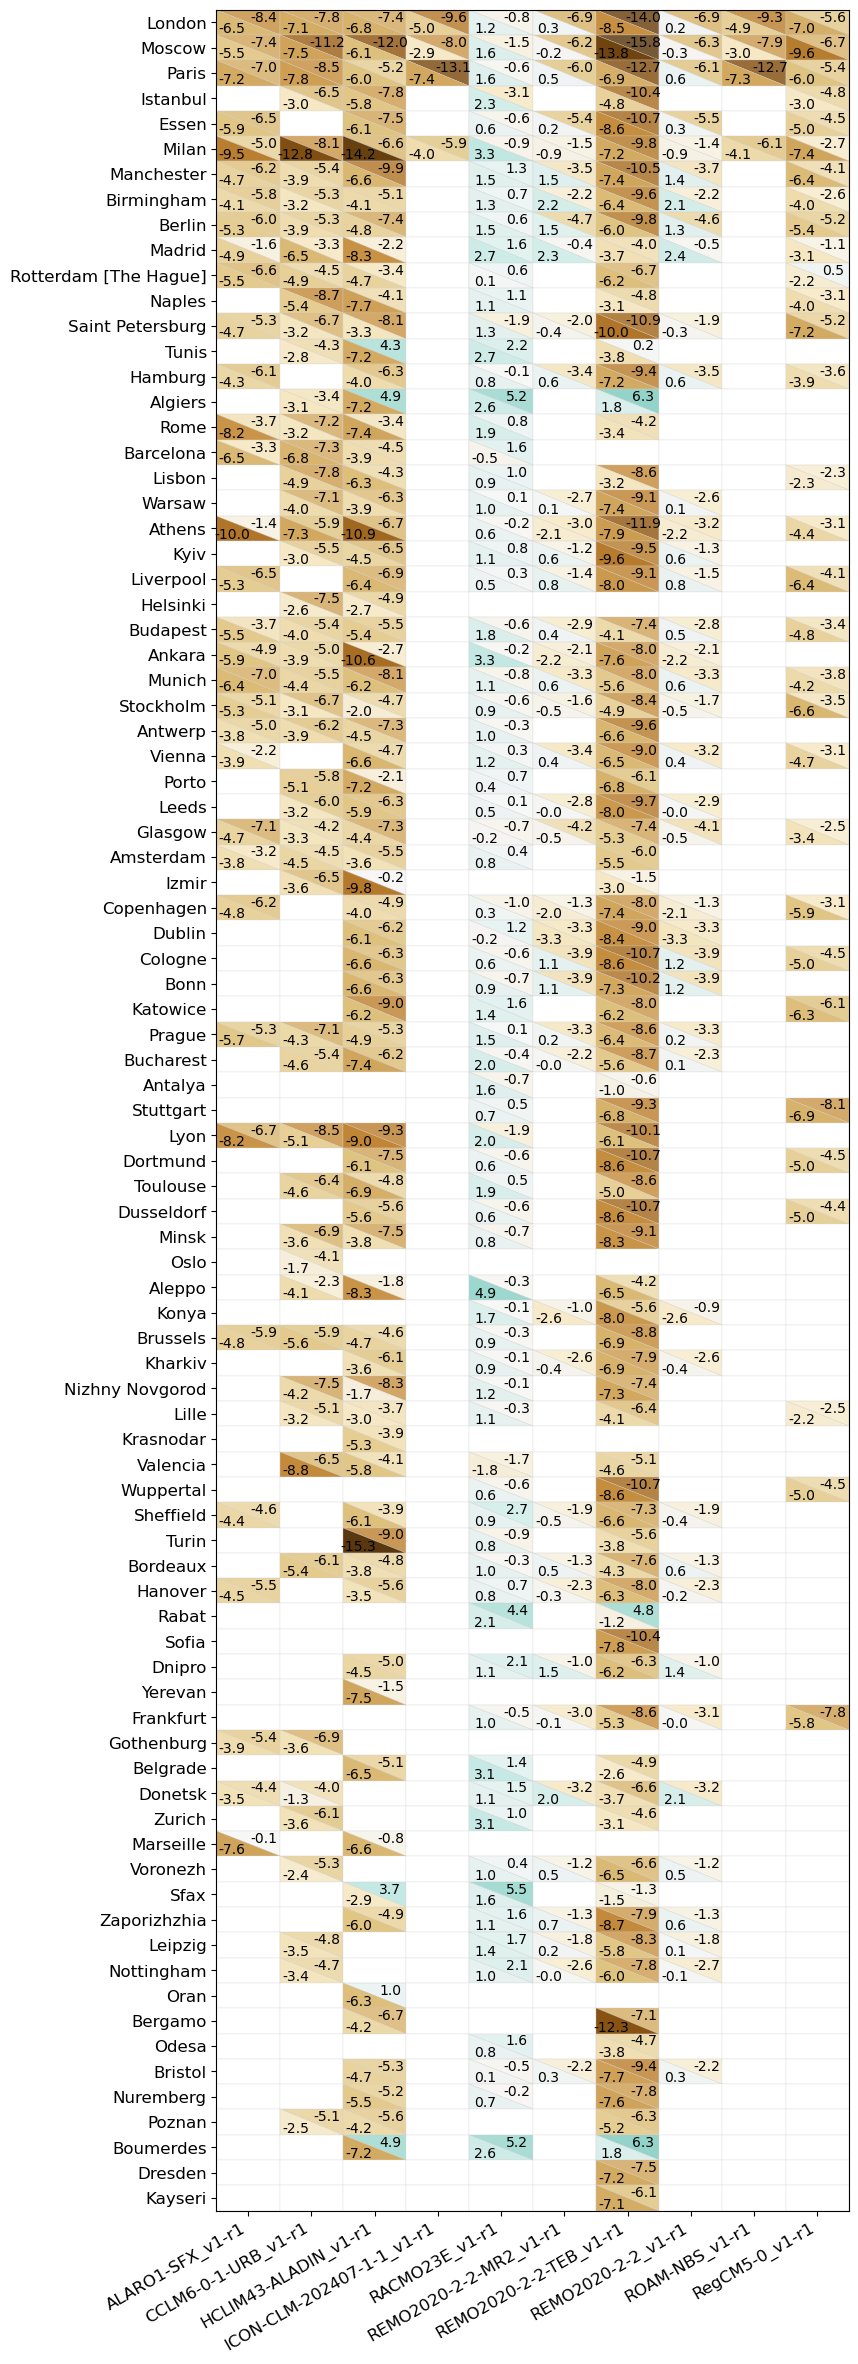

In [12]:
# =============================================================================
# Heatmap of Mean Seasonal Anomalies (JJA and DJF)
# =============================================================================
# This script creates a grid-like heatmap where each cell represents the mean
# seasonal anomaly for a given city (row) and RCM (column).
# The upper triangle of each cell shows the summer (JJA) mean anomaly, while
# the lower triangle shows the winter (DJF) mean anomaly.
# The city named "default" is skipped.
# Observations are not included.
# =============================================================================

# --- Configuration ---
if variable in ['tasmin','tasmax']:
    colormap = plt.cm.bwr
    vmin, vmax = -5, 5
elif variable == 'sfcWind':
    colormap = plt.cm.PiYG
    vmin, vmax = -1.5, 1.5
else:
    colormap = plt.cm.BrBG
    vmin, vmax = -15, 15
    
# --- Filter out the "default" city ---
valid_cities = [city for city in cities if city.lower() != "default"]

# --- Create output directory ---
save_summary_path = os.path.join(save_figure_path, "summaries")
os.makedirs(save_summary_path, exist_ok=True)

# --- Initialize figure ---
nrows = len(valid_cities)
ncols = len(rcm_names)

fig_width = max(12, ncols*7)
fig_height = min(30, nrows*0.25)
fig, ax = plt.subplots(figsize=(fig_width, fig_height))


# --- Initialize data matrices ---
summer_means = np.full((nrows, ncols), np.nan)
winter_means = np.full((nrows, ncols), np.nan)

# =============================================================================
# Data Extraction
# =============================================================================
for i, city in enumerate(valid_cities):
    for j, rcm_name in enumerate(rcm_names):

        # --- Define dataset paths ---
        nc_path = f"{save_figure_dataset}/Annual_cycle/CMIP6_{city}_Annual_cycle_{variable}_{rcm_name}_{period.start}-{period.stop}.nc"
        urmask_path = f"{save_figure_dataset}/urmask/CMIP6_{city}_urmask_{rcm_name}.nc"

        if not (os.path.exists(nc_path) and os.path.exists(urmask_path)):
            continue

        try:
            # --- Load data ---
            ds_anomaly = xr.open_dataset(nc_path)[variable]
            urmask = xr.open_dataset(urmask_path)

            # --- Align coordinates ---
            ds_anomaly = ds_anomaly.assign_coords({
                urmask.cf['X'].name: urmask[urmask.cf['X'].name],
                urmask.cf['Y'].name: urmask[urmask.cf['Y'].name]
            })

            # --- Apply urban mask ---
            is_urban = urmask['urmask'] == 1
            urban_anomaly = ds_anomaly.where(is_urban)

            # --- Compute spatial mean ---
            urban_mean = urban_anomaly.mean(
                dim=[ds_anomaly.cf['Y'].name, ds_anomaly.cf['X'].name]
            ).compute()

            # --- Extract months ---
            months = urban_mean['time.month'].values if 'time' in urban_mean.dims else np.arange(1, 13)
            values = urban_mean.values

            # --- Calculate mean for JJA and DJF ---
            jja_mask = np.isin(months, [6, 7, 8])
            djf_mask = np.isin(months, [12, 1, 2])

            summer_mean = np.nanmean(values[jja_mask])
            winter_mean = np.nanmean(values[djf_mask])

            summer_means[i, j] = summer_mean
            winter_means[i, j] = winter_mean

        except Exception as e:
            print(f"Error in {city} - {rcm_name}: {e}")
            continue

# =============================================================================
# Visualization
# =============================================================================
valid_city_mask = ~np.logical_and(
    np.isnan(summer_means).all(axis=1),
    np.isnan(winter_means).all(axis=1)
)

# Aplicar máscara
summer_means = summer_means[valid_city_mask, :]
winter_means = winter_means[valid_city_mask, :]
valid_cities_filtered = [city for i, city in enumerate(valid_cities) if valid_city_mask[i]]

# Actualizar número de filas
nrows = len(valid_cities_filtered)

ax.set_xlim(0, ncols)
ax.set_ylim(0, nrows)
ax.set_xticks(np.arange(ncols) + 0.5)
ax.set_yticks(np.arange(nrows) + 0.5)
ax.set_xticklabels(rcm_names, rotation=30, ha='right', fontsize=12)
ax.set_yticklabels(valid_cities_filtered, fontsize=12)
ax.invert_yaxis()
ax.set_aspect(0.4)  
# --- Draw cells with split triangles ---
for i in range(nrows):
    for j in range(ncols):
        x0, y0 = j, i
        summer_val = summer_means[i, j]
        winter_val = winter_means[i, j]

        # --- Handle missing data (draw grey background) ---
        if np.isnan(summer_val) and np.isnan(winter_val):
            rect = Polygon(
                [(x0, y0), (x0 + 1, y0), (x0 + 1, y0 + 1), (x0, y0 + 1)],
                closed=True, facecolor="white", edgecolor='lightgray', linewidth=0.2
            )
            ax.add_patch(rect)
            continue

        # --- Colors (add alpha = 0.5 for clarity) ---
        def with_alpha(color, alpha=0.8):
            return (*color[:3], alpha)

        summer_color = with_alpha(colormap((summer_val - vmin) / (vmax - vmin))) if not np.isnan(summer_val) else (1, 1, 1, 0)
        winter_color = with_alpha(colormap((winter_val - vmin) / (vmax - vmin))) if not np.isnan(winter_val) else (1, 1, 1, 0)

        # --- Draw upper (summer) triangle ---
        summer_tri = Polygon(
            [(x0, y0), (x0 + 1, y0), (x0 + 1, y0 + 1)],
            closed=True, facecolor=summer_color, edgecolor='lightgray', linewidth=0.2
        )
        ax.add_patch(summer_tri)

        # --- Draw lower (winter) triangle ---
        winter_tri = Polygon(
            [(x0, y0), (x0, y0 + 1), (x0 + 1, y0 + 1)],
            closed=True, facecolor=winter_color, edgecolor='lightgray', linewidth=0.2
        )
        ax.add_patch(winter_tri)

        # --- Draw lower (winter) triangle ---
        winter_tri = Polygon(
            [(x0, y0), (x0, y0 + 1), (x0 + 1, y0 + 1)],
            closed=True, facecolor=winter_color, edgecolor='lightgray', linewidth=0.2
        )
        ax.add_patch(winter_tri)

        # --- Annotate numeric values ---
        if not np.isnan(summer_val):
            ax.text(x0 + 0.75, y0 + 0.30, f"{summer_val:.1f}",
                    ha='center', va='center', fontsize=10, color='black')
        if not np.isnan(winter_val):
            ax.text(x0 + 0.25, y0 + 0.75, f"{winter_val:.1f}",
                    ha='center', va='center', fontsize=10, color='black')


sm = plt.cm.ScalarMappable(cmap=colormap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
#cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.03, pad=0.02, shrink=0.3)

units = {
    "tasmin": "K",
    "tasmax": "K",
    "pr": "% (mm/day)",
    "sfcWind": "m s⁻¹",
    "hurs": "%"

}.get(variable, "")

#cbar.set_label( f"{variable}-anomaly ({units})", fontsize=16)

plt.tight_layout()

# --- Save figure ---
output_png_path = os.path.join(
    save_summary_path,
    f"CMIP6_Heatmap_AllCities_{variable}_{period.start}-{period.stop}.png"
)
plt.savefig(output_png_path, dpi=300, bbox_inches="tight")
print(f"Heatmap saved to: {output_png_path}")
# Save figure
output_pdf = os.path.join(
    save_summary_path,
    f"CMIP6_Heatmap_AllCities_{variable}_{period.start}-{period.stop}.pdf"
)
plt.savefig(output_pdf, format="pdf", bbox_inches="tight")
print(f"Figure saved at: {output_pdf}")

Saved: /mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/urban-evaluation/plots/summaries/CMIP6_Map_Compare_hurs_1991-2020.png
Figure saved at: /mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/urban-evaluation/plots/summaries/CMIP6_Map_Compare_hurs_1991-2020.pdf


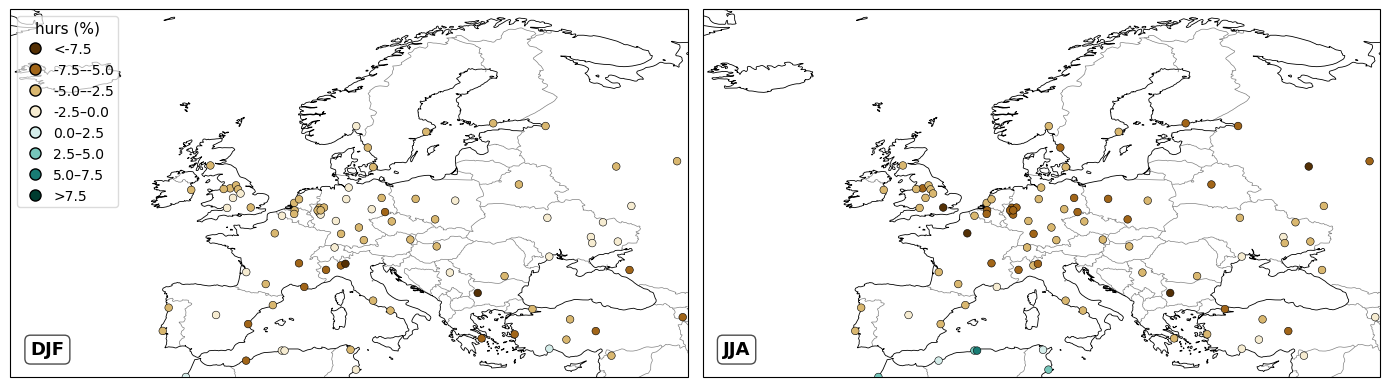

In [13]:
# --- Preparar DataFrame con lon, lat y medias ---
df_map = gdf_sorted[["GC_UCN_MAI_2025", "geometry_centroid"]].copy()
df_map["lon"] = df_map.geometry.x
df_map["lat"] = df_map.geometry.y

# Filtrar solo las ciudades válidas
df_map = df_map[df_map["GC_UCN_MAI_2025"].isin(valid_cities_filtered)].copy()

# Alinear con los valores medios
df_map["summer_mean"] = [np.nanmean(summer_means[i, :]) for i in range(len(valid_cities_filtered))]
df_map["winter_mean"] = [np.nanmean(winter_means[i, :]) for i in range(len(valid_cities_filtered))]

# --- Colormap discreto ---
if variable in ["tasmin", "tasmax"]:
    colormap = plt.cm.Reds
    vmin, vmax =  0, 3
    step = 0.5
elif variable == "sfcWind":
    colormap = plt.cm.PiYG
    vmin, vmax = -2, 2
    step = 0.5
else:
    colormap = plt.cm.BrBG
    vmin, vmax = -10, 10
    step = 2.5

levels = np.arange(vmin, vmax + step, step)
norm = BoundaryNorm(levels, ncolors=colormap.N, clip=True)

# --- Crear figura con dos mapas ---
fig, axes = plt.subplots(
    1, 2, figsize=(14, 6),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

cols = ["winter_mean", "summer_mean"]
labels_inside = ["DJF", "JJA"]

for ax, value_col, label in zip(axes, cols, labels_inside):
    # Fondo (sin mar)
    ax.add_feature(cfeature.LAND, facecolor="white")
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor="gray")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="black")
    ax.set_extent([-25, 45, 34, 72], crs=ccrs.PlateCarree())

    # Puntos de ciudad
    sc = ax.scatter(
        df_map["lon"], df_map["lat"],
        c=df_map[value_col],
        cmap=colormap,
        norm=norm,
        s=30,
        edgecolor="black",
        linewidth=0.4,
        transform=ccrs.PlateCarree(),
        zorder=3
    )

    # Etiqueta dentro del mapa (esquina inferior izquierda)
    ax.text(
        0.03, 0.05, label,
        transform=ax.transAxes,
        fontsize=13, fontweight="bold",
        color="black",
        ha="left", va="bottom",
        bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3", alpha=0.7)
    )

units = {
    "tasmin": "K",
    "tasmax": "K",
    "pr": "% (mm/day)",
    "sfcWind": "m s⁻¹",
    "hurs": "%"
}.get(variable, "")
# --- Leyenda discreta tipo puntos en recuadro ---
from matplotlib.lines import Line2D

# Etiquetas de intervalos (ejemplo: <0.5, 0.5–1.0, …, >2.5)
interval_labels = [f"<{levels[1]}"]
for i in range(1, len(levels) - 1):
    interval_labels.append(f"{levels[i]}–{levels[i+1]}")
interval_labels[-1] = f">{levels[-2]}"

# Colores representativos de cada intervalo
colors = [colormap(norm((a + b) / 2)) for a, b in zip(levels[:-1], levels[1:])]

# Crear handles (puntos de color)
handles = [
    Line2D([0], [0], marker='o', color='none',
           markerfacecolor=c, markersize=8, label=lab)
    for c, lab in zip(colors, interval_labels)
]

# Añadir leyenda (cuadro)
axes[0].legend(
    handles=handles,
    title=f"{variable} ({units})",
    title_fontsize=11,
    loc='upper left',     # <- esquina superior izquierda
    frameon=True,
    fontsize=10,
    handletextpad=0.3,
    borderpad=0.3,
    framealpha=0.7
)

plt.tight_layout(rect=[0, 0.08, 1, 1])  # más espacio debajo
plt.subplots_adjust(bottom=0.30)        # margen extra inferior

# --- Guardar figura ---
output_png_path = os.path.join(
    save_summary_path,
    f"CMIP6_Map_Compare_{variable}_{period.start}-{period.stop}.png"
)
plt.savefig(output_png_path, dpi=300, bbox_inches="tight")
print(f"Saved: {output_png_path}")

# Save figure
output_pdf = os.path.join(
    save_summary_path,
    f"CMIP6_Map_Compare_{variable}_{period.start}-{period.stop}.pdf"
)
plt.savefig(output_pdf, format="pdf", bbox_inches="tight")
print(f"Figure saved at: {output_pdf}")

## Boxplots

In [14]:
root_aux_data = "/mnt/CORDEX_CMIP6_tmp/aux_data/"
ucdb_path = f"{root_aux_data}GHS_FUA_UCD/GHS_UCDB_GLOBE_R2024A.gpkg"

# Load UCDB layers
gdf_centroids = gpd.read_file(ucdb_path, layer="UC_centroids")
gdf_char = gpd.read_file(ucdb_path, layer="GHS_UCDB_THEME_GENERAL_CHARACTERISTICS_GLOBE_R2024A")

# Clean column names
gdf_centroids.columns = gdf_centroids.columns.str.strip().str.replace("﻿", "", regex=True)
gdf_char.columns = gdf_char.columns.str.strip().str.replace("﻿", "", regex=True)

# Reproject to WGS84
gdf_centroids = gdf_centroids.to_crs(epsg=4326)

# Merge centroid geometry with characteristics
gdf_merged = gdf_char.merge(
    gdf_centroids[["ID_UC_G0", "geometry"]],
    on="ID_UC_G0",
    suffixes=("_char", "_centroid")
)

# Set the geometry to the centroid geometry
gdf_merged = gdf_merged.set_geometry("geometry_centroid")

# Extract lon/lat for filtering
lon_tmp = gdf_merged.geometry.x
lat_tmp = gdf_merged.geometry.y


# Filter cities by area and Europe bounding box
gdf_filtered = gdf_merged[gdf_merged["GC_UCA_KM2_2025"] >= 12.5 * 12.5].copy()
gdf_europe = gdf_filtered[
    (lat_tmp >= 34) & (lat_tmp <= 72) &
    (lon_tmp >= -25) & (lon_tmp <= 45)
].copy()


# ----------------------------------------------------------------------
# PREPARE CITY-COUNTRY LIST
# ----------------------------------------------------------------------
def clean_string(s):
    if isinstance(s, str):
        return s.strip().replace("\ufeff", "")
    return s

gdf_europe["GC_UCN_MAI_2025"] = gdf_europe["GC_UCN_MAI_2025"].apply(clean_string)
gdf_europe["GC_CNT_GAD_2025"] = gdf_europe["GC_CNT_GAD_2025"].apply(clean_string)
city_country_list = list(zip(gdf_europe["GC_UCN_MAI_2025"], gdf_europe["GC_CNT_GAD_2025"]))
print(f"Filtered European cities (≥144 km²): {len(gdf_europe)}")



Filtered European cities (≥144 km²): 95


/home/yquintana/.conda/envs/jsc/lib/python3.10/site-packages/geopandas/geodataframe.py:1896: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)


### Classification of Cities: Coastal

In [15]:
ds_sftlf = xr.open_dataset("/mnt/CORDEX_CMIP6_tmp/sim_data/CORDEX-CMIP6/DD/EUR-12/ICTP/MPI-ESM1-2-HR/historical/r1i1p1f1/RegCM5-0/v1-r1/fx/sftlf/v20250415/sftlf_EUR-12_MPI-ESM1-2-HR_historical_r1i1p1f1_ICTP_RegCM5-0_v1-r1_fx.nc") 

In [16]:
def is_coastal_from_sftlf_2D(polygon, ds_sftlf, max_dist_km=11.5):
    """
    Determines if an urban area (defined by a polygon) is coastal based on the 
    presence of both low and high land fraction (sftlf) values within a proximity buffer.
    polygon: Polygon o MultiPolygon (en cualquier CRS)
        ds_sftlf (xarray.Dataset): Dataset containing the 'sftlf' variable and 2D lon/lat coordinates.
        max_dist_km (float): The search radius around the polygon, expressed in kilometers.
    """
    geom_gs = gpd.GeoSeries([polygon], crs="ESRI:54009").to_crs(epsg=4326)
    poly = geom_gs.iloc[0]
    
    # Buffer
    buffer_deg = max_dist_km / 111.0
    
    # Coordenadates of sftlf
    lon = ds_sftlf.lon.values
    lat = ds_sftlf.lat.values
    sftlf = ds_sftlf.sftlf.values
    
    #create mask of point inside the polygon with the buffer
    points_inside = []
    for j in range(lat.shape[0]):
        for i in range(lon.shape[1]):
            # punto lon/lat
            x, y = lon[j,i], lat[j,i]
            # solo puntos dentro del bbox + buffer
            if (poly.bounds[0]-buffer_deg <= x <= poly.bounds[2]+buffer_deg) and \
               (poly.bounds[1]-buffer_deg <= y <= poly.bounds[3]+buffer_deg):
                points_inside.append((x,y,sftlf[j,i]))
    
    if not points_inside:
        return False
    
    sftlf_vals = np.array([p[2] for p in points_inside])
    return (np.nanmax(sftlf_vals) > 70) and (np.nanmin(sftlf_vals) < 70)


In [17]:
gdf_europe["is_coastal"] = gdf_europe["geometry_char"].apply(
    lambda geom: is_coastal_from_sftlf_2D(geom, ds_sftlf)
)

/tmp/ipykernel_92670/305897762.py:56: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/tmp/ipykernel_92670/305897762.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


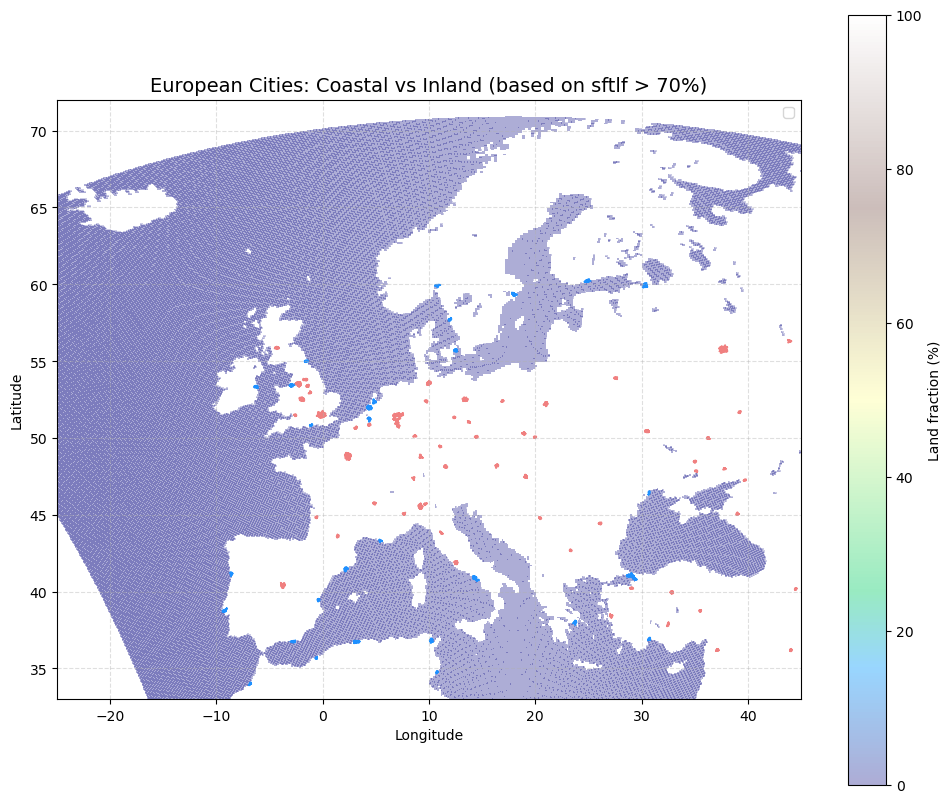

In [18]:
# Prepare GeoDataFrame for plotting: copy data, set initial CRS, and convert to WGS84
gdf_plot = gpd.GeoDataFrame(
    gdf_europe.copy(), 
    geometry="geometry_char", 
    crs="ESRI:54009"
).to_crs(epsg=4326)

# Initialize plot figure and axes
fig, ax = plt.subplots(figsize=(12, 10))

# --- Plot Land Fraction (sftlf) ---
# Extract coordinates and sftlf data
lon = ds_sftlf.lon.values
lat = ds_sftlf.lat.values
sftlf = ds_sftlf.sftlf.values

# Plot sftlf data using pcolormesh for background visualization
mesh = ax.pcolormesh(
    lon, 
    lat, 
    sftlf, 
    cmap="terrain", 
    alpha=0.4, 
    shading="auto"
)

# Add colorbar for sftlf
cbar = plt.colorbar(mesh, ax=ax, label="Land fraction (%)")

# --- Plot Cities by Classification ---
# Plot Coastal cities (is_coastal = True)
gdf_plot[gdf_plot["is_coastal"]].plot(
    ax=ax, 
    color="dodgerblue", 
    edgecolor="dodgerblue", 
    label="Coastal cities"
)

# Plot Inland cities (is_coastal = False)
gdf_plot[~gdf_plot["is_coastal"]].plot(
    ax=ax, 
    color="lightcoral", 
    edgecolor="lightcoral", 
    label="Inland cities"
)

# --- Final Map Settings ---
# Set map limits to focus on Europe
ax.set_xlim(-25, 45)
ax.set_ylim(33, 72)

# Set title, labels, legend, and grid
ax.set_title("European Cities: Coastal vs Inland (based on sftlf > 70%)", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)

# Display the plot
plt.show()

### Classification of Cities: Mountain

In [19]:
ds_orog = xr.open_dataset("/mnt/CORDEX_CMIP6_tmp/sim_data/CORDEX-CMIP6/DD/EUR-12/ICTP/MPI-ESM1-2-HR/historical/r1i1p1f1/RegCM5-0/v1-r1/fx/orog/v20250415/orog_EUR-12_MPI-ESM1-2-HR_historical_r1i1p1f1_ICTP_RegCM5-0_v1-r1_fx.nc") 

In [20]:
import numpy as np
# Assuming the 'ds_orog' xarray Dataset and 'gdf_europe' GeoDataFrame are loaded

def get_elevation_from_orog_2d(point, ds):
    """
    Retrieves elevation from 2D xarray grid based on the nearest grid cell to a given point.
    
    Args:
        point (shapely Point): City centroid geometry.
        ds (xarray.Dataset): Dataset containing orog (elevation), lat, and lon (2D arrays).
    
    Returns:
        float: Elevation value at the nearest grid point.
    """
    # Calculate squared approximate Euclidean distance in degrees to find the nearest grid point
    dist2 = (ds.lat - point.y)**2 + (ds.lon - point.x)**2
    
    # Get the 2D indices (y_idx, x_idx) of the minimum distance
    y_idx, x_idx = np.unravel_index(dist2.argmin().item(), dist2.shape)
    
    # Return the elevation value (orog) at the identified index
    return float(ds.orog[y_idx, x_idx].values)

# --- Application ---

# Apply the function to the city centroids to calculate the nearest elevation and store it
gdf_europe["elevation"] = gdf_europe.geometry_centroid.apply(
    lambda p: get_elevation_from_orog_2d(p, ds_orog)
)

# --- Classification ---

# Classify cities as 'is_mountain' if their elevation is 500 meters or higher
gdf_europe["is_mountain"] = gdf_europe["elevation"] >= 500

/tmp/ipykernel_92670/2305096709.py:61: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/tmp/ipykernel_92670/2305096709.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


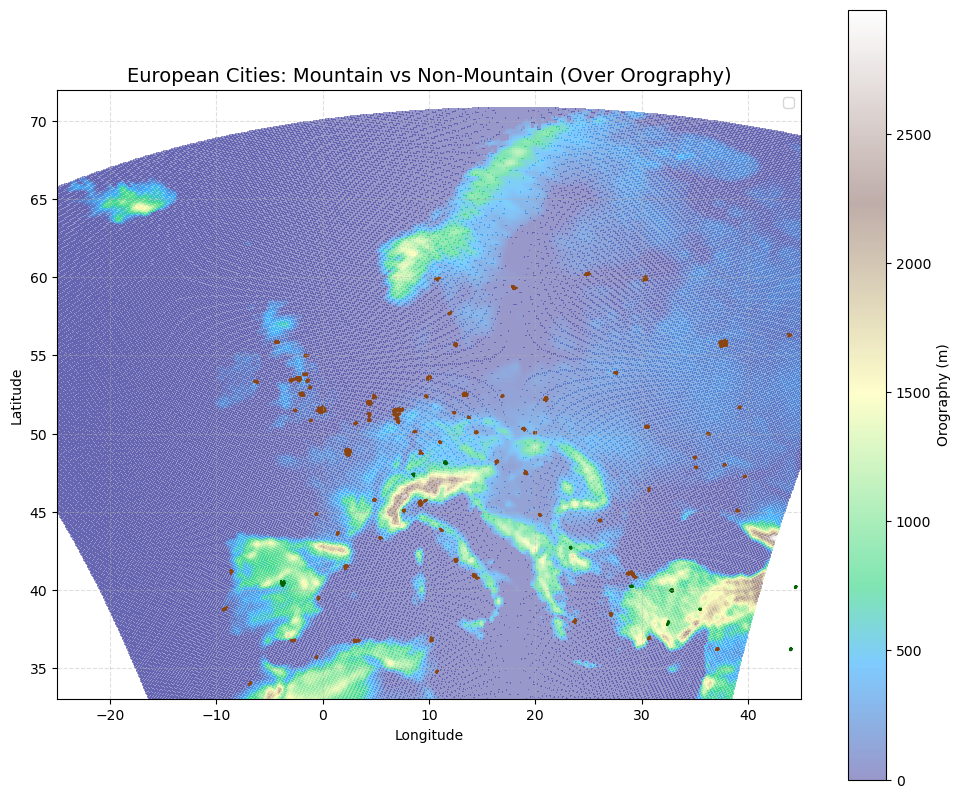

In [21]:
# Prepare GeoDataFrame: copy data, set initial CRS (ESRI:54009 assumed), and convert to WGS84 (EPSG:4326)
gdf_plot = gpd.GeoDataFrame(
    gdf_europe.copy(), 
    geometry="geometry_char", 
    crs="ESRI:54009"
).to_crs(epsg=4326)

# Initialize plot figure and axes
fig, ax = plt.subplots(figsize=(12, 10))

# --- Plot Orography (orog) ---
# Extract 2D coordinates and orography data
lon = ds_orog.lon.values
lat = ds_orog.lat.values
orog = ds_orog.orog.values  # Elevation variable (meters)

# Plot orography data using pcolormesh for background visualization
mesh = ax.pcolormesh(
    lon, 
    lat, 
    orog, 
    cmap="terrain", 
    alpha=0.5, 
    shading="auto"
)

# Add colorbar for orography
cbar = plt.colorbar(mesh, ax=ax, label="Orography (m)")

# --- Plot Cities by Classification ---
# Plot Mountain cities (is_mountain = True)
# NOTE: The labels below should be updated to reflect 'is_mountain' classification
gdf_plot[gdf_plot["is_mountain"]].plot(
    ax=ax, 
    color="darkgreen", # Changed color for visual distinction of mountains
    edgecolor="darkgreen", 
    label="Mountain cities" 
)

# Plot Non-Mountain cities (is_mountain = False)
gdf_plot[~gdf_plot["is_mountain"]].plot(
    ax=ax, 
    color="saddlebrown", # Changed color for visual distinction
    edgecolor="saddlebrown", 
    label="Non-mountain cities"
)

# --- Final Map Settings ---
# Set map limits to focus on Europe
ax.set_xlim(-25, 45)
ax.set_ylim(33, 72)

# Set title, labels, legend, and grid (Title corrected to reflect 'is_mountain' plotting)
ax.set_title("European Cities: Mountain vs Non-Mountain (Over Orography)", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)

# Display the plot
plt.show()

We have successfully completed the initial geographical classification of all analyzed European cities. This process involved the creation of two distinct binary classification variables:

    Coastal: Cities located on or near a major coastline (is_coastal = True).

    Mountainous: Cities whose elevation meets or exceeds the defined threshold (e.g., ≥500 m) (is_mountain = True).

    Inland: The remaining cities, which are neither classified as Coastal nor as Mountainous, fall into the Inland category. These cities represent the purely continental environment within the dataset.

In [22]:
gdf_europe["is_inland"] = (~gdf_europe["is_coastal"]) & (~gdf_europe["is_mountain"])

In [23]:
def get_city_type(row):
    if row["is_mountain"]:
        return "Mountain"
    elif row["is_coastal"]:
        return "Coastal"
    elif row["is_inland"]:
        return "Inland"

gdf_europe["city_type"] = gdf_europe.apply(get_city_type, axis=1)

In [24]:
period = pd.Interval(left=1991, right=2020, closed='both')

### Model Configuration

In [25]:
# =============================================================================
# LOAD AND PREPARE EURO-CORDEX MODEL METADATA
# =============================================================================
csv_path = "eurocordex_models.csv"

# Read the CSV file using comma as separator and handling commented lines
try:
    models_df = pd.read_csv(csv_path, sep=",", engine="python", comment="#")
except FileNotFoundError:
    raise FileNotFoundError(f"Configuration file not found at: {csv_path}")

# Define and verify the presence of all required columns for processing
required_cols = {"model", "mip_era", "color"}
if not required_cols.issubset(set(models_df.columns)):
    raise RuntimeError(
        f"Missing required columns in {csv_path}. Required columns: {required_cols}. "
        f"Columns found: {models_df.columns.tolist()}"
    )

# Filter the entire model list to retain only models from the CMIP6 experiment
models_cmip6 = models_df[models_df["mip_era"] == "CMIP6"].copy()

# --- Filter CMIP6 Models to Match RCMs ---
# Extract the base names of the available Regional Climate Models (RCMs)
rcm_base_names = [name.split("_v")[0] for name in rcm_names]

# Filter the CMIP6 models to include only those whose base name matches the available RCMs
models_plot = models_cmip6[models_cmip6["model"].isin(rcm_base_names)].copy()

# --- Data Cleaning ---
# Define a utility function to ensure color strings are correctly formatted (prefixed with '#')
def clean_color(c):
    """Ensures color string is correctly formatted, adding '#' prefix if missing."""
    s = str(c).strip()
    if s and not s.startswith("#"):
        return "#" + s
    return s

# Apply the cleaning function to the 'color' column of the plotting subset
models_plot["color"] = models_plot["color"].apply(clean_color)

## Plot a boxplot for each variable

### Load the data

In [26]:
# =============================================================================
# SETTINGS
# =============================================================================
vmin, vmax = -3, 3
variables = ["tasmin", "tasmax",  'sfcWind', 'hurs']  # Variables que quieres plotear

save_summary_path = os.path.join(save_figure_path, "summaries")
os.makedirs(save_summary_path, exist_ok=True)

# =============================================================================
# DATA EXTRACTION
# =============================================================================
records = []

for variable in variables:
    for city, city_type in zip(gdf_europe["GC_UCN_MAI_2025"], gdf_europe["city_type"]):
        # Sanitizar nombre de ciudad para archivo
        city_file = city

        for rcm_name in rcm_names:
            nc_path = f"{save_figure_dataset}/Annual_cycle/CMIP6_{city_file}_Annual_cycle_{variable}_{rcm_name}_{period.left}-{period.right}.nc"
            urmask_path = f"{save_figure_dataset}/urmask/CMIP6_{city_file}_urmask_{rcm_name}.nc"
            if not (os.path.exists(nc_path) and os.path.exists(urmask_path)):
                continue

            try:
                # --- Load data ---
                ds_anomaly = xr.open_dataset(nc_path)[variable]
                urmask = xr.open_dataset(urmask_path)

                # --- Align coordinates ---
                ds_anomaly = ds_anomaly.assign_coords({
                    urmask.cf['X'].name: urmask[urmask.cf['X'].name],
                    urmask.cf['Y'].name: urmask[urmask.cf['Y'].name]
                })

                # --- Apply urban mask ---
                is_urban = urmask['urmask'] == 1
                if is_urban.sum() == 0:
                    continue

                urban_anomaly = ds_anomaly.where(is_urban)

                # --- Compute spatial mean ---
                urban_mean = urban_anomaly.mean(
                    dim=[ds_anomaly.cf['Y'].name, ds_anomaly.cf['X'].name]
                ).compute()

                # --- Extract months ---
                if 'time' in urban_mean.dims:
                    months = urban_mean['time.month'].values
                    values = urban_mean.values
                else:
                    months = np.arange(1, 13)
                    values = urban_mean.values
                    if values.ndim == 0:
                        values = np.array([values])

                # --- Calculate mean for JJA and DJF ---
                jja_mask = np.isin(months, [6, 7, 8])
                djf_mask = np.isin(months, [12, 1, 2])

                summer_mean = np.nan if values[jja_mask].size == 0 else np.nanmean(values[jja_mask])
                winter_mean = np.nan if values[djf_mask].size == 0 else np.nanmean(values[djf_mask])

                # --- Store records ---
                records.append({
                    "City": city,
                    "City_Type": city_type,
                    "Model": rcm_name,
                    "Variable": variable,
                    "Season": "Summer (JJA)",
                    "Value": summer_mean
                })
                records.append({
                    "City": city,
                    "City_Type": city_type,
                    "Model": rcm_name,
                    "Variable": variable,
                    "Season": "Winter (DJF)",
                    "Value": winter_mean
                })

            except Exception as e:
                print(f"Error in {city} - {rcm_name} - {variable}: {e}")
                continue

/tmp/ipykernel_92670/3653280496.py:70: RuntimeWarning: Mean of empty slice
  summer_mean = np.nan if values[jja_mask].size == 0 else np.nanmean(values[jja_mask])
/tmp/ipykernel_92670/3653280496.py:71: RuntimeWarning: Mean of empty slice
  winter_mean = np.nan if values[djf_mask].size == 0 else np.nanmean(values[djf_mask])
/tmp/ipykernel_92670/3653280496.py:70: RuntimeWarning: Mean of empty slice
  summer_mean = np.nan if values[jja_mask].size == 0 else np.nanmean(values[jja_mask])
/tmp/ipykernel_92670/3653280496.py:71: RuntimeWarning: Mean of empty slice
  winter_mean = np.nan if values[djf_mask].size == 0 else np.nanmean(values[djf_mask])
/tmp/ipykernel_92670/3653280496.py:70: RuntimeWarning: Mean of empty slice
  summer_mean = np.nan if values[jja_mask].size == 0 else np.nanmean(values[jja_mask])
/tmp/ipykernel_92670/3653280496.py:71: RuntimeWarning: Mean of empty slice
  winter_mean = np.nan if values[djf_mask].size == 0 else np.nanmean(values[djf_mask])
/tmp/ipykernel_92670/3653280

### Plot the data

/tmp/ipykernel_92670/1444161076.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


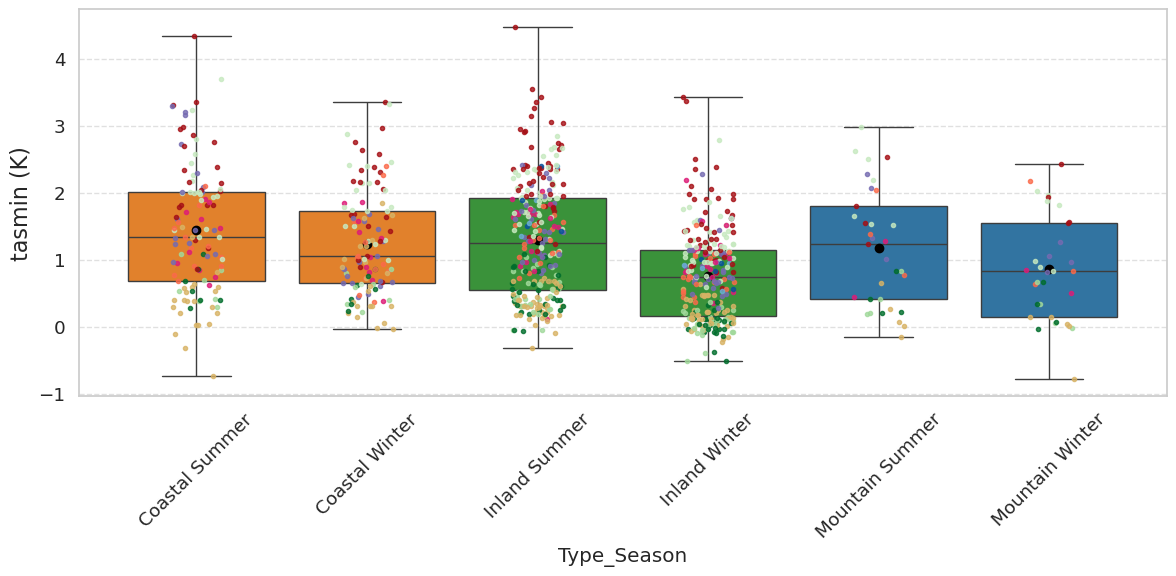

/tmp/ipykernel_92670/1444161076.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


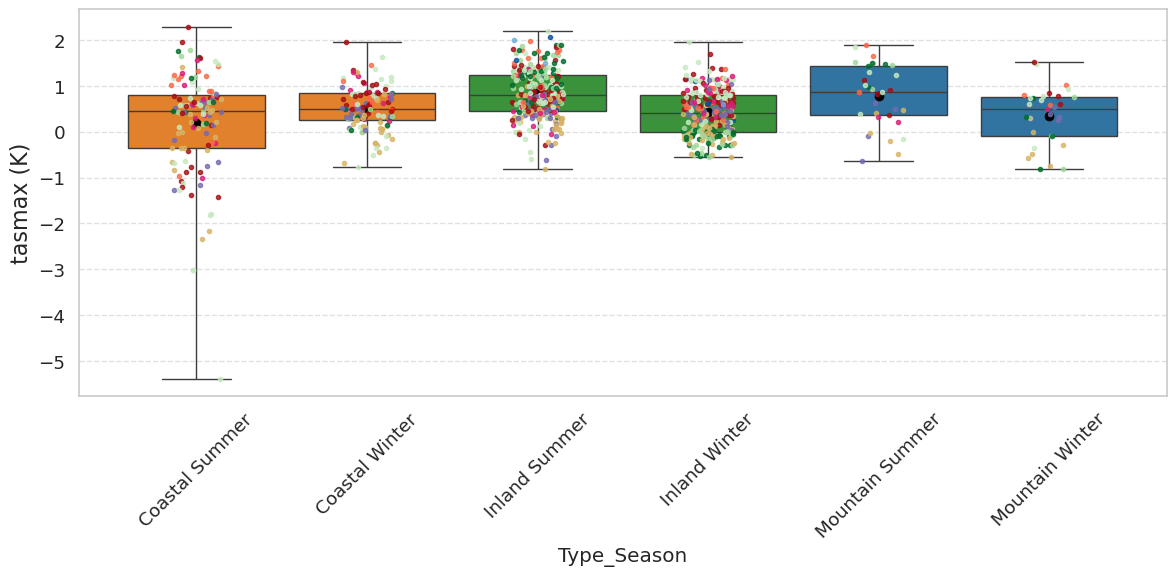

/tmp/ipykernel_92670/1444161076.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


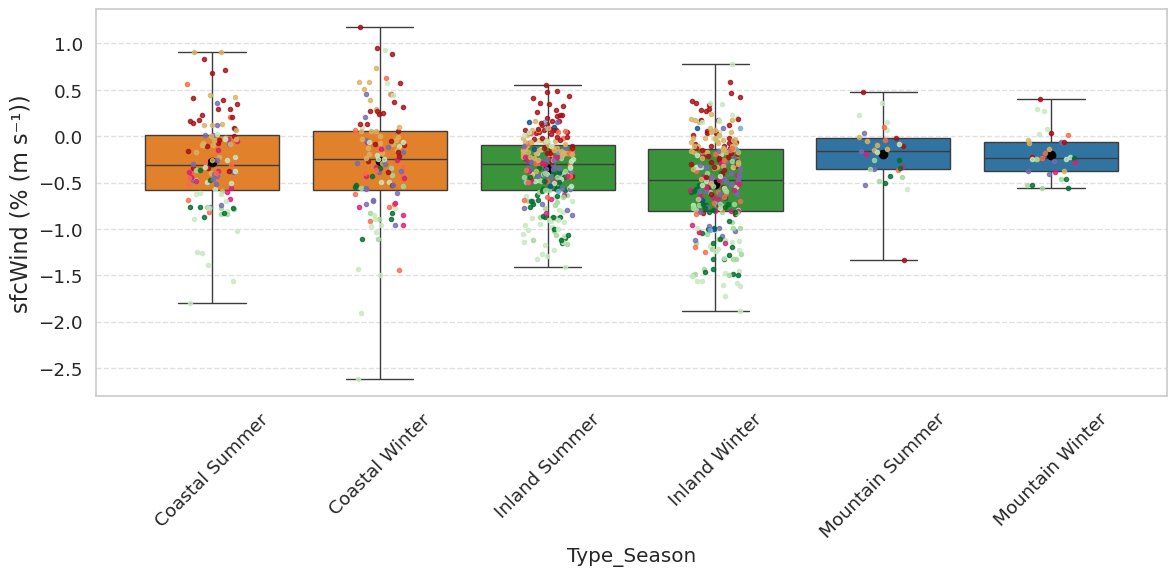

/tmp/ipykernel_92670/1444161076.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


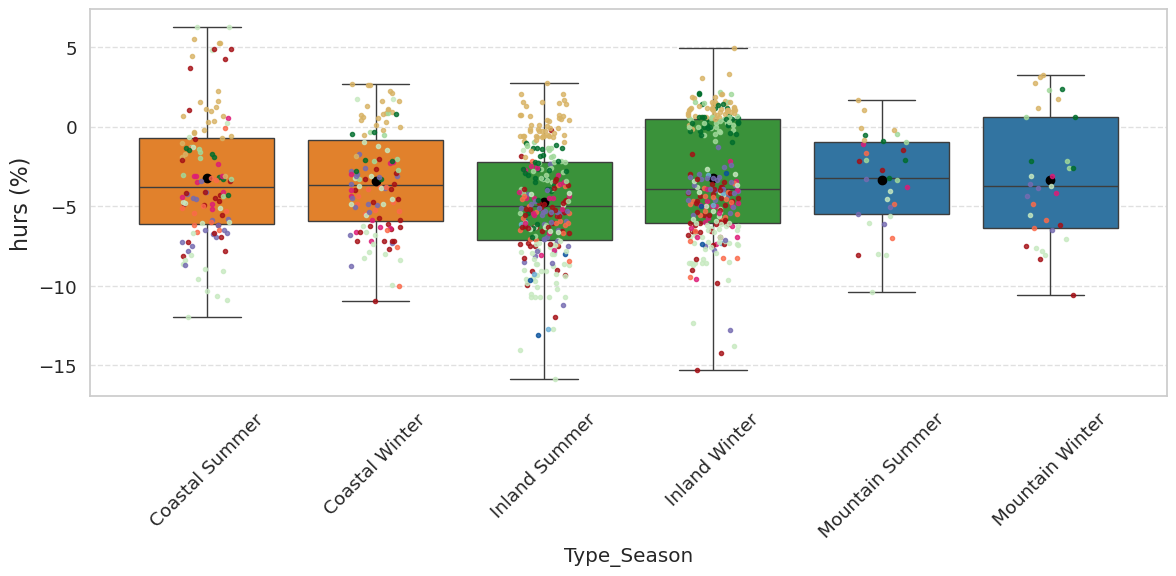

In [27]:
# =============================================================================
# CARGAR Y PREPARAR MODELOS EURO-CORDEX
# =============================================================================
csv_path = "eurocordex_models.csv"

# Leer CSV correctamente con coma
models_df = pd.read_csv(csv_path, sep=",", engine="python")

# Filtrar CMIP6
models_cmip6 = models_df[models_df["mip_era"] == "CMIP6"].copy()

rcm_names = [
    'ALARO1-SFX_v1-r1', 'CCLM6-0-1-URB_v1-r1', 'HCLIM43-ALADIN_v1-r1',
    'ICON-CLM-202407-1-1_v1-r1', 'RACMO23E_v1-r1',
    'REMO2020-2-2-MR2_v1-r1', 'REMO2020-2-2-TEB_v1-r1',
    'REMO2020-2-2_v1-r1', 'ROAM-NBS_v1-r1', 'RegCM5-0_v1-r1'
]
rcm_base_names = [name.split("_v")[0] for name in rcm_names]

# Filtrar los modelos CMIP6 coincidentes
models_plot = models_cmip6[models_cmip6["model"].isin(rcm_base_names)].copy()

# Limpiar columna de color
def clean_color(c):
    if pd.isna(c):
        return "#000000"
    s = str(c).strip()
    if not s.startswith("#"):
        s = "#" + s
    if len(s) != 7 or not all(ch in "0123456789ABCDEFabcdef#" for ch in s):
        return "#000000"
    return s

models_plot["color"] = models_plot["color"].apply(clean_color)
model_color_map = dict(zip(models_plot["model"], models_plot["color"]))

# =============================================================================
# CREAR DATAFRAME PARA BOXPLOT
# =============================================================================
df_box = pd.DataFrame(records)

if not df_box.empty:
    # Combinar tipo de ciudad y temporada
    df_box["Type_Season"] = df_box["City_Type"] + " " + df_box["Season"].str.replace(r"\s\(.+\)", "", regex=True)

    sns.set(style="whitegrid", font_scale=1.2)

    # Colores por tipo de ciudad
    city_colors = {
        "Mountain": "#1f77b4",  # azul
        "Coastal": "#ff7f0e",   # naranja
        "Inland": "#2ca02c",    # verde
    }

    # Orden de categorías
    type_season_order = [f"{t} {s}" for t in ["Coastal", "Inland", "Mountain"] for s in ["Summer", "Winter"]]

    for variable in variables:
        plt.figure(figsize=(12, 6))
        data_plot = df_box[df_box["Variable"] == variable]

        if data_plot.empty:
            plt.close()
            continue

        # --- Boxplot con colores según tipo de ciudad y whiskers completos ---
        palette = [city_colors.get(ts.split()[0], "#777777") for ts in type_season_order]
        sns.boxplot(
            data=data_plot,
            x="Type_Season",
            y="Value",
            order=type_season_order,
            showfliers=False,
            showmeans=True,
            meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"},
            palette=palette,
            whis=[0, 100]  # whiskers del mínimo al máximo
        )

        # --- Puntos individuales por modelo ---
        for i, ts in enumerate(type_season_order):
            subset = data_plot[data_plot["Type_Season"] == ts]
            for _, row in subset.iterrows():
                model_name = row["Model"] if "Model" in row else None
                color = model_color_map.get(model_name.split("_v")[0], "#444444") if model_name else "#444444"
                jitter = (random.random() - 0.5) * 0.3
                plt.plot(i + jitter, row["Value"], 'o', color=color, alpha=0.8, markersize=3, zorder=4)

        # --- Opciones de plot ---
        units = {
            "tasmin": "K",
            "tasmax": "K",
            "pr": "% (mm/day)",
            "sfcWind": "% (m s⁻¹)",
            "hurs": "%"
        }.get(variable, "")

        plt.ylabel(f"{variable} ({units})", fontsize=16)
        plt.grid(True, axis="y", linestyle="--", alpha=0.6)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

else:
    print("df_box empty")


/tmp/ipykernel_92670/1740601303.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bp = sns.boxplot(
/tmp/ipykernel_92670/1740601303.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bp = sns.boxplot(
/tmp/ipykernel_92670/1740601303.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bp = sns.boxplot(
/tmp/ipykernel_92670/1740601303.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bp = sns.boxplot(


Figure saved to: /mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/urban-evaluation/plots/summaries/CMIP6_Boxplot_AllCities_AllVariables_1991-2020.png
Figure saved to: /mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/urban-evaluation/plots/summaries/CMIP6_Boxplot_AllCities_AllVariables_1991-2020.pdf


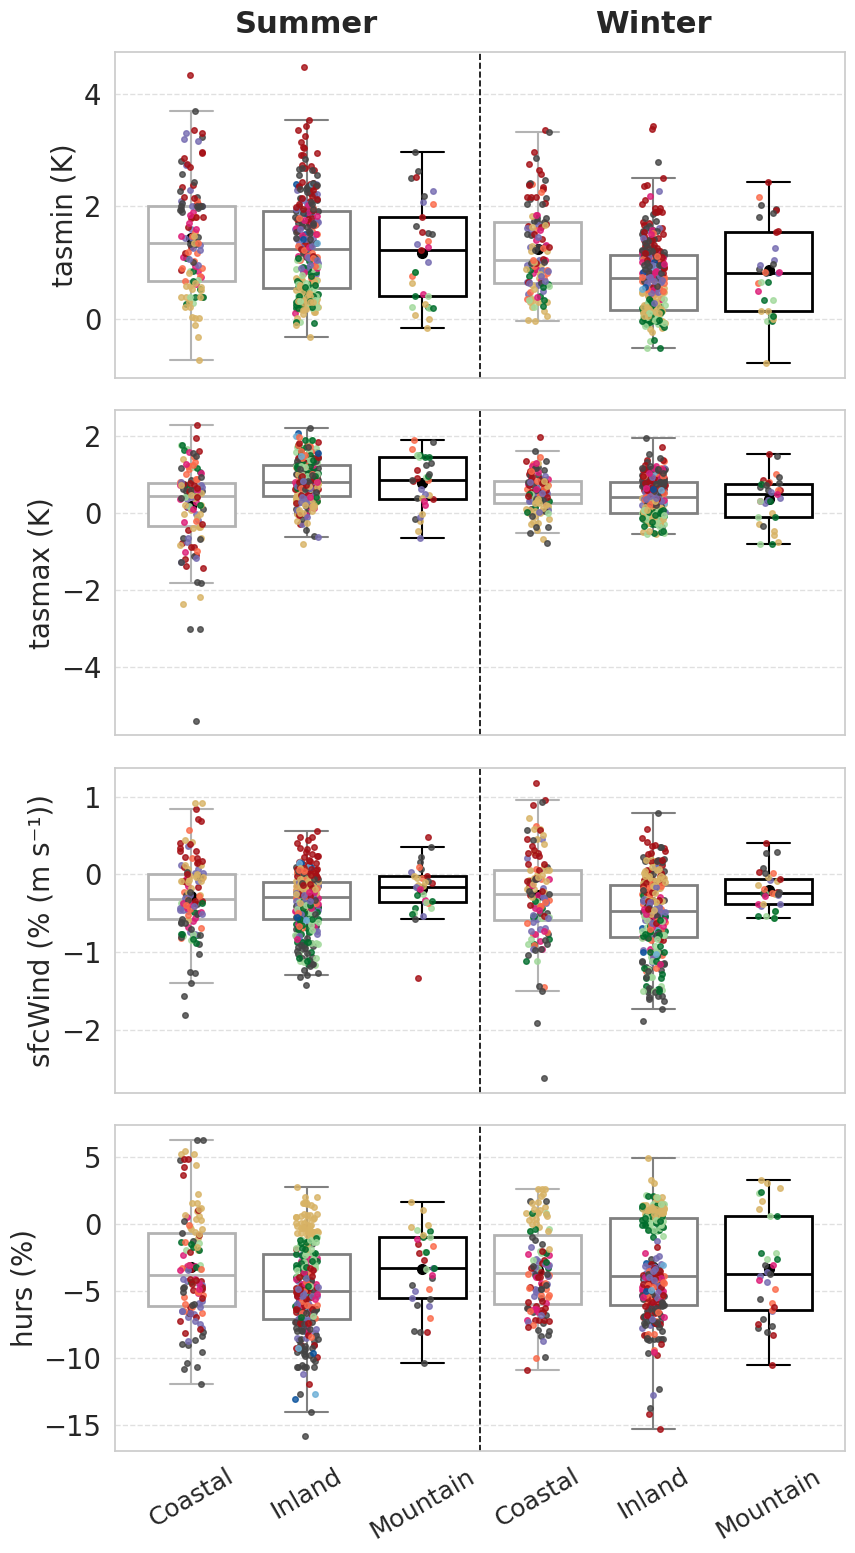

In [28]:
# =============================================================================
# MODEL CONFIGURATION: LOAD AND PREPARE EURO-CORDEX METADATA
# =============================================================================
csv_path = "eurocordex_models.csv"
# Load the model metadata from CSV
models_df = pd.read_csv(csv_path, sep=",", engine="python")

# Filter the DataFrame to retain only CMIP6 models
models_cmip6 = models_df[models_df["mip_era"] == "CMIP6"].copy()

# List of Regional Climate Models (RCMs) of interest
rcm_names = [
    'ALARO1-SFX_v1-r1', 'CCLM6-0-1-URB_v1-r1', 'HCLIM43-ALADIN_v1-r1',
    'ICON-CLM-202407-1-1_v1-r1', 'RACMO23E_v1-r1', 'REMO2020-2-2-MR2_v1-r1',
    'REMO2020-2-2_v1-r1', 'ROAM-NBS_v1-r1', 'RegCM5-0_v1-r1'
]
# Extract the base model names (without version suffixes)
rcm_base_names = [name.split("_v")[0] for name in rcm_names]

# Filter CMIP6 models to select only those matching the RCM base names for plotting
models_plot = models_cmip6[models_cmip6["model"].isin(rcm_base_names)].copy()

# --- Color Cleaning Utility ---
def clean_color(c):
    """Ensures color string is a valid 7-character hex code, defaulting on fail."""
    if pd.isna(c):
        return "#0000FF" # Default to blue if NaN
    s = str(c).strip()
    if not s.startswith("#"):
        s = "#" + s
    # Validate hex format (length 7 and correct characters)
    if len(s) != 7 or not all(ch in "0123456789ABCDEFabcdef#" for ch in s):
        return "#000000" # Default to black if validation fails
    return s

# Apply color cleaning and create a dictionary mapping model names to their colors
models_plot["color"] = models_plot["color"].apply(clean_color)
model_color_map = dict(zip(models_plot["model"], models_plot["color"]))

# =============================================================================
# BOXPLOT DATA PREPARATION
# =============================================================================
# Assume 'records' is a list of dictionaries containing model output data
df_box = pd.DataFrame(records)

if not df_box.empty:
    # Combine Season and City_Type for x-axis categories (e.g., "Summer Coastal")
    df_box["Type_Season"] = df_box["Season"].str.replace(r"\s\(.+\)", "", regex=True) + " " + df_box["City_Type"]

    # =============================================================================
    # BOXPLOT GENERATION (FACETED BY VARIABLE)
    # =============================================================================
    sns.set(style="whitegrid", font_scale=1.8)
    
    # Define category order for plotting
    city_types = ["Coastal", "Inland", "Mountain"]
    seasons = ["Summer", "Winter"]
    # Create the explicit order for the x-axis categories
    type_season_order = [f"{s} {t}" for s in seasons for t in city_types]

    # Define Grayscale Color Mapping for Boxplot Edges
    # Grayscale levels: 0=black, 0.5=medium gray, 0.7=light gray
    gray_levels = ["0.7", "0.5", "0.0"] # Coastal (light), Inland (medium), Mountain (dark)
    city_color_map = {t: g for t, g in zip(city_types, gray_levels)}
    
    # Create the ordered palette for Seaborn (to set color order, though we override faces later)
    palette_ordered = [city_color_map.get(ts.split()[1], "0.5") for ts in type_season_order]
    
    # Figure size calculations
    n_per_season = len(city_types)
    variables = df_box["Variable"].unique()
    n_vars = len(variables)
    
    fig_width = 3 * n_per_season
    fig_height = 4.2 * n_vars
    
    # Create a figure with subplots (one row per variable), sharing the x-axis
    fig, axes = plt.subplots(n_vars, 1, figsize=(fig_width, fig_height), sharex=True)
    if n_vars == 1:
        axes = [axes] # Ensure axes is iterable even for a single subplot
    
    # --- Plotting Loop ---
    for ax, variable in zip(axes, variables):
        data_plot = df_box[df_box["Variable"] == variable]
        if data_plot.empty:
            continue

        # 1. Generate Boxplot with White Interior
        # Use a white palette to set the face color to white initially
        bp = sns.boxplot(
            data=data_plot,
            x="Type_Season",
            y="Value",
            order=type_season_order,
            ax=ax,
            width=0.75,
            showfliers=False,
            showmeans=True,
            meanprops={
                "marker": "o",
                "markerfacecolor": "black",
                "markeredgecolor": "black",
                "markersize": 7
            },
            palette=["white"] * len(type_season_order),
            linewidth=1.3
        )
        
        # 2. Apply Grayscale Edges to Boxes and Lines
        for i, patch in enumerate(ax.patches):
            ts = type_season_order[i]
            gray = city_color_map[ts.split()[1]] # Get grayscale level for the city type
            
            # Set box face (interior) to white and edge (border) to the assigned grayscale
            patch.set_facecolor("white")
            patch.set_edgecolor(gray)
            patch.set_linewidth(2.0)
            
            # Adjust colors for whiskers, caps, and median lines
            # Lines are indexed in groups of 6 per box (whiskers, caps, median, mean)
            lines = ax.lines[i * 6: i * 6 + 6]
            for j, line in enumerate(lines):
                line.set_color(gray)
                # Set median line (index 4) slightly thicker
                line.set_linewidth(2.0 if j == 4 else 1.5)
        
        # 3. Overlay Individual Model Points
        for i, ts in enumerate(type_season_order):
            subset = data_plot[data_plot["Type_Season"] == ts]
            for _, row in subset.iterrows():
                model_name = row.get("Model", "")
                # Get model color from the prepared map using the base name
                color = model_color_map.get(model_name.split("_v")[0], "#444444")
                
                # Apply random jitter for point separation on the x-axis
                jitter = (random.random() - 0.5) * 0.2
                
                # Plot the point
                ax.plot(i + jitter, row["Value"], 'o', color=color, alpha=0.8, markersize=4, zorder=4)
        
        # 4. Add Visual Separator between Summer and Winter
        ax.axvline(n_per_season - 0.5, color="black", linestyle="--", lw=1.2)
        
        # 5. X-Axis Labels and Aesthetics
        ax.set_xticks(range(len(type_season_order)))
        # Display only the city type in the x-axis labels
        ax.set_xticklabels([ts.split()[1] for ts in type_season_order], fontsize=18, rotation=30)
        ax.set_xlabel("") # Remove the general x-axis label
        
        # 6. Y-Axis Label, Units, and Grid
        units = {
            "tasmin": "K",
            "tasmax": "K",
            "pr": "% (mm/day)",
            "sfcWind": "% (m s⁻¹)",
            "hurs": "%",
        }.get(variable, "")
        ax.set_ylabel(f"{variable} ({units})", fontsize=20)
        ax.grid(True, axis="y", linestyle="--", alpha=0.6)
    
    # --- Final Figure Aesthetics (Applied to the top subplot) ---
    # Add season labels (Summer/Winter) above the top subplot
    top_ax = axes[0]
    ylim = top_ax.get_ylim()
    # Calculate center positions for the season labels
    summer_center = (0 + (n_per_season - 1)) / 2
    winter_center = summer_center + n_per_season
    
    # Place season labels
    top_ax.text(summer_center, ylim[1] * 1.05, "Summer", ha="center", va="bottom", fontsize=22, fontweight="bold")
    top_ax.text(winter_center, ylim[1] * 1.05, "Winter", ha="center", va="bottom", fontsize=22, fontweight="bold")
    
    # Adjust layout to prevent clipping, especially for the top labels
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    # -----------------------------------------------------------------------------
    # SAVE FIGURE
    # Note: 'save_summary_path' and 'period' are assumed to be defined in the context
    # -----------------------------------------------------------------------------
    
    filename_base = f"CMIP6_Boxplot_AllCities_AllVariables_{period.left}-{period.right}"
    
    # Save as PNG
    output_png_path = os.path.join(save_summary_path, f"{filename_base}.png")
    fig.savefig(output_png_path, dpi=300, bbox_inches="tight")
    print(f"Figure saved to: {output_png_path}")
    
    # Save as PDF
    output_pdf_path = os.path.join(save_summary_path, f"{filename_base}.pdf")
    fig.savefig(output_pdf_path, dpi=300, bbox_inches="tight")
    print(f"Figure saved to: {output_pdf_path}")

else:
    print("df_box is empty; no data available for plotting.")

## Analysis and Plots by Urban Area

This section shifts the focus from categorical geographical classification to a quantitative analysis based on the urban area of the cities. The urban area size, measured by the number of grid cells covered, acts as a primary metric for studying scale-dependent effects.

### Load the data

In [29]:
# =============================================================================
# SETTINGS
# =============================================================================
vmin, vmax = -3, 3

save_summary_path = os.path.join(save_figure_path, "summaries")
os.makedirs(save_summary_path, exist_ok=True)

# =============================================================================
# DATA EXTRACTION
# =============================================================================

records = []

for variable in variables:
    for city, city_type in zip(gdf_europe["GC_UCN_MAI_2025"], gdf_europe["city_type"]):
        # Sanitizar nombre de ciudad para archivo
        city_file = city

        for rcm_name in rcm_names:
            nc_path = f"{save_figure_dataset}/Annual_cycle/CMIP6_{city_file}_Annual_cycle_{variable}_{rcm_name}_{period.left}-{period.right}.nc"
            urmask_path = f"{save_figure_dataset}/urmask/CMIP6_{city_file}_urmask_{rcm_name}.nc"

            if not (os.path.exists(nc_path) and os.path.exists(urmask_path)):
                continue

            try:
                # --- Load data ---
                ds_anomaly = xr.open_dataset(nc_path)[variable]
                urmask = xr.open_dataset(urmask_path)

                # --- Align coordinates ---
                ds_anomaly = ds_anomaly.assign_coords({
                    urmask.cf['X'].name: urmask[urmask.cf['X'].name],
                    urmask.cf['Y'].name: urmask[urmask.cf['Y'].name]
                })

                # --- Apply urban mask ---
                is_urban = urmask['urmask'] == 1
                urban_cells = int(is_urban.sum().values)  # <--- NEW: count urban grid cells
                if urban_cells == 0:
                    continue

                urban_anomaly = ds_anomaly.where(is_urban)

                # --- Compute spatial mean ---
                urban_mean = urban_anomaly.mean(
                    dim=[ds_anomaly.cf['Y'].name, ds_anomaly.cf['X'].name]
                ).compute()

                # --- Extract months ---
                if 'time' in urban_mean.dims:
                    months = urban_mean['time.month'].values
                    values = urban_mean.values
                else:
                    months = np.arange(1, 13)
                    values = urban_mean.values
                    if values.ndim == 0:
                        values = np.array([values])

                # --- Calculate mean for JJA and DJF ---
                jja_mask = np.isin(months, [6, 7, 8])
                djf_mask = np.isin(months, [12, 1, 2])

                summer_mean = np.nan if values[jja_mask].size == 0 else np.nanmean(values[jja_mask])
                winter_mean = np.nan if values[djf_mask].size == 0 else np.nanmean(values[djf_mask])

                # --- Store records ---
                records.append({
                    "City": city,
                    "City_Type": city_type,
                    "Model": rcm_name,
                    "Variable": variable,
                    "Season": "Summer (JJA)",
                    "Value": summer_mean,
                    "urban_cells": urban_cells  
                })
                records.append({
                    "City": city,
                    "City_Type": city_type,
                    "Model": rcm_name,
                    "Variable": variable,
                    "Season": "Winter (DJF)",
                    "Value": winter_mean,
                    "urban_cells": urban_cells  
                })

            except Exception as e:
                print(f"Error in {city} - {rcm_name} - {variable}: {e}")
                continue


/tmp/ipykernel_92670/2900012140.py:72: RuntimeWarning: Mean of empty slice
  summer_mean = np.nan if values[jja_mask].size == 0 else np.nanmean(values[jja_mask])
/tmp/ipykernel_92670/2900012140.py:73: RuntimeWarning: Mean of empty slice
  winter_mean = np.nan if values[djf_mask].size == 0 else np.nanmean(values[djf_mask])
/tmp/ipykernel_92670/2900012140.py:72: RuntimeWarning: Mean of empty slice
  summer_mean = np.nan if values[jja_mask].size == 0 else np.nanmean(values[jja_mask])
/tmp/ipykernel_92670/2900012140.py:73: RuntimeWarning: Mean of empty slice
  winter_mean = np.nan if values[djf_mask].size == 0 else np.nanmean(values[djf_mask])
/tmp/ipykernel_92670/2900012140.py:72: RuntimeWarning: Mean of empty slice
  summer_mean = np.nan if values[jja_mask].size == 0 else np.nanmean(values[jja_mask])
/tmp/ipykernel_92670/2900012140.py:73: RuntimeWarning: Mean of empty slice
  winter_mean = np.nan if values[djf_mask].size == 0 else np.nanmean(values[djf_mask])
/tmp/ipykernel_92670/2900012

### Scatter plot for each variable

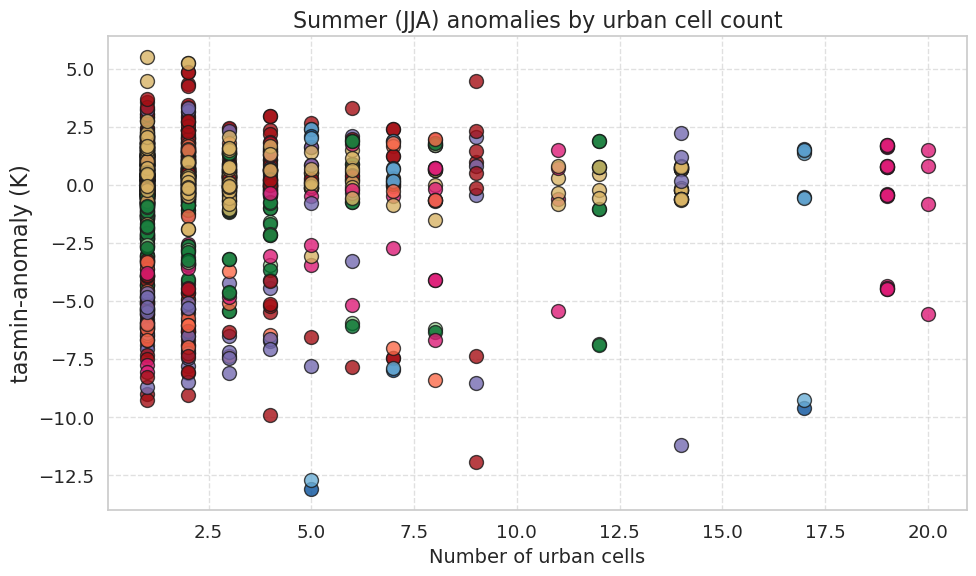

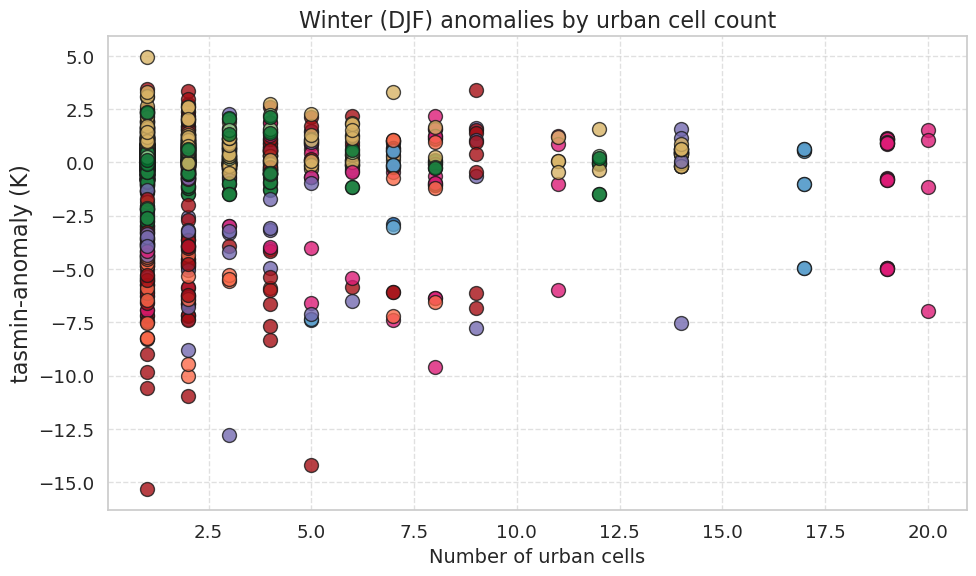

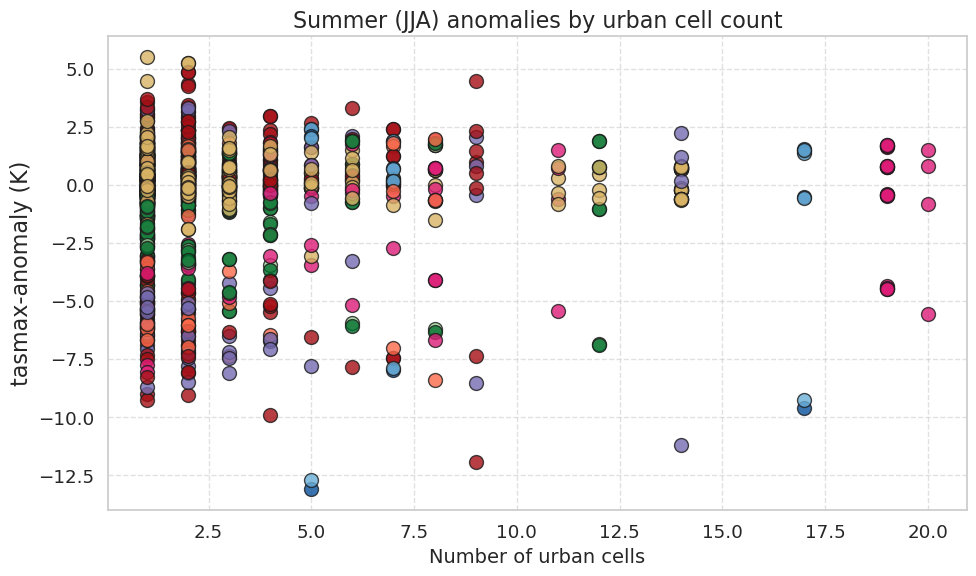

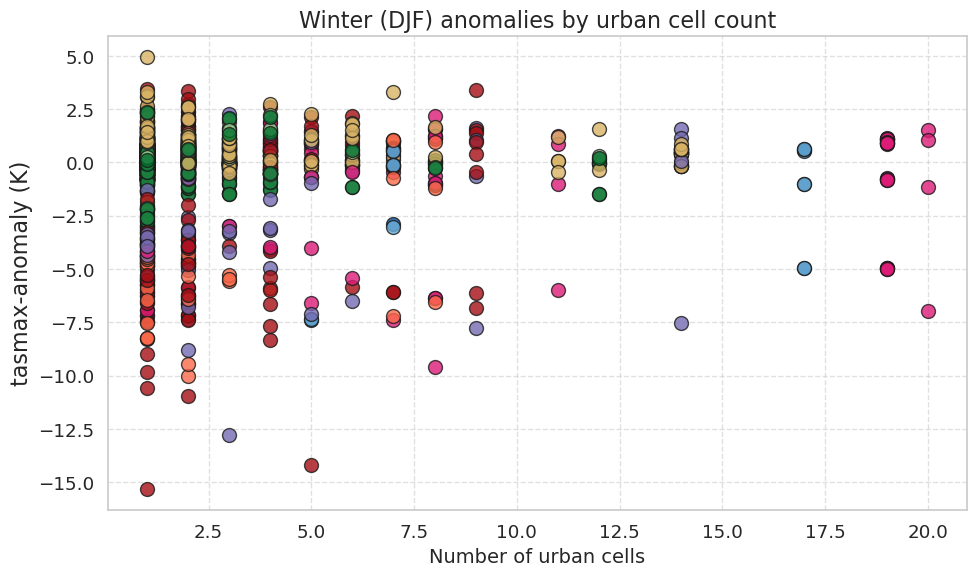

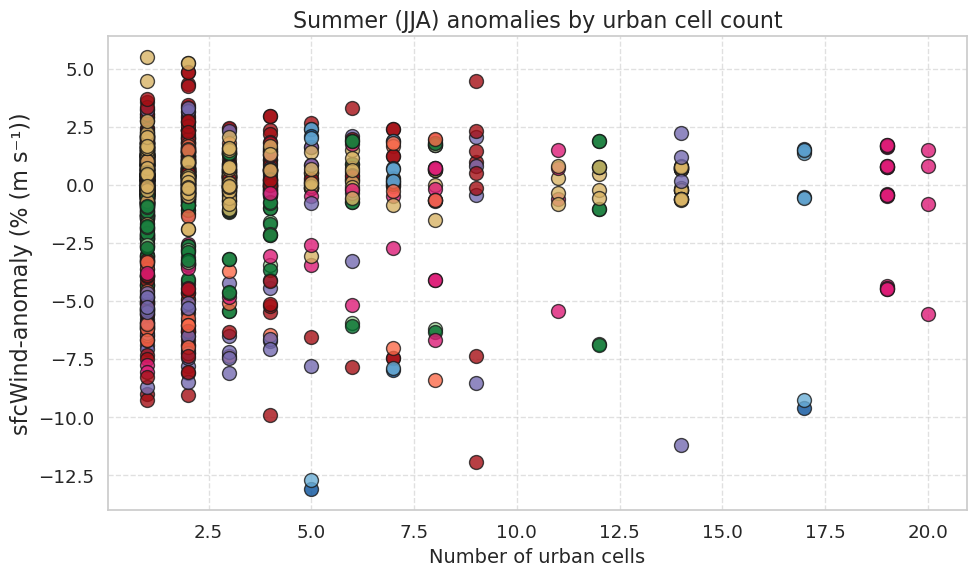

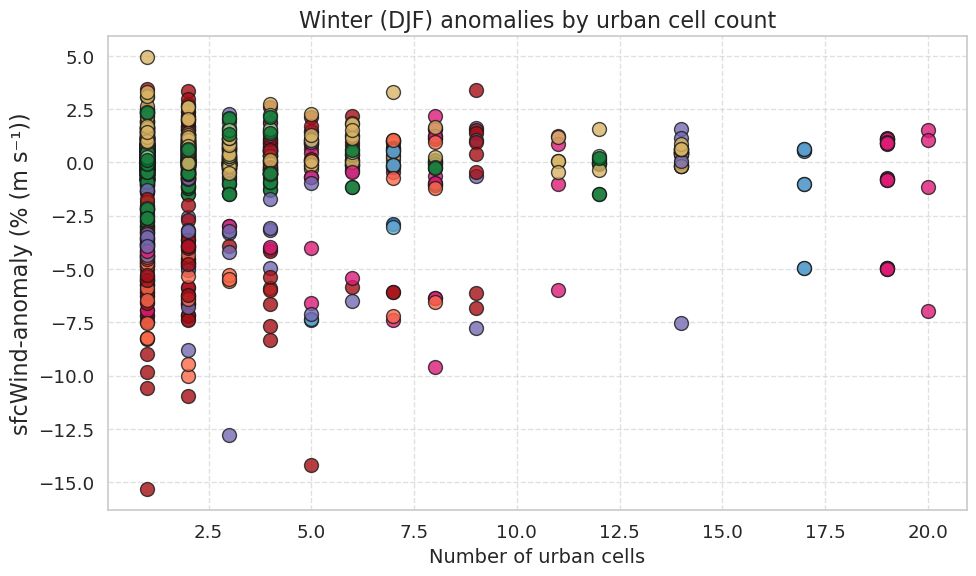

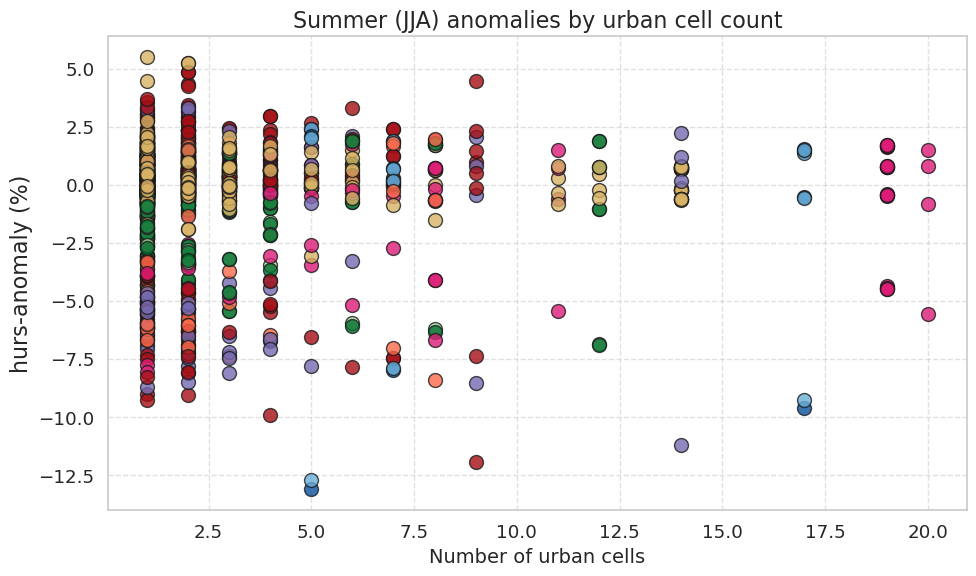

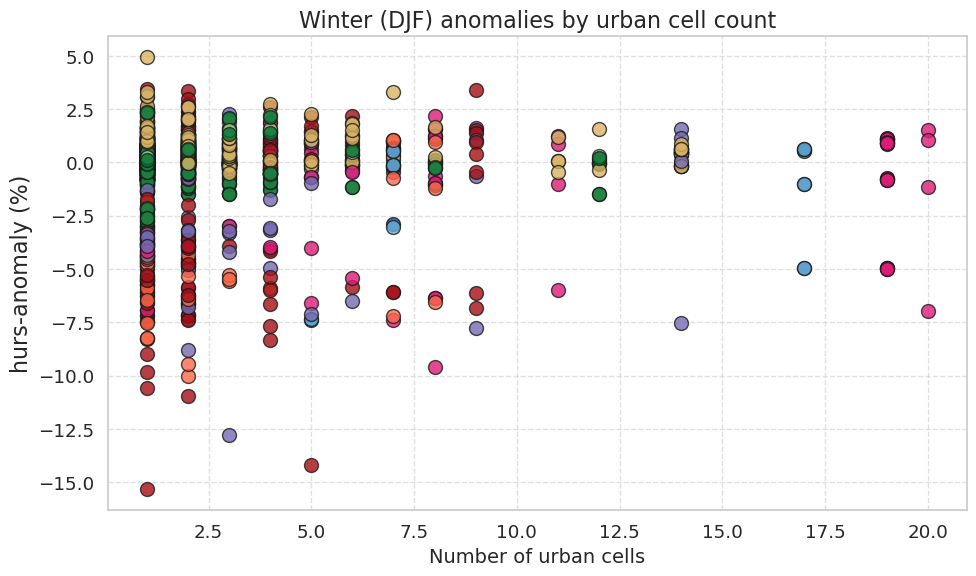

In [30]:
# =============================================================================
# LIMPIEZA DE df_box
# =============================================================================
df_box = pd.DataFrame(records).copy()

# Limpiar valores no numéricos o enmascarados
df_box["Value"] = df_box["Value"].apply(
    lambda x: np.nan if (isinstance(x, np.ma.MaskedArray) or np.ma.is_masked(x)) else x
)
df_box = df_box.dropna(subset=["Value"])

# Asegurar tipo de ciudad
df_box["City_Type"] = df_box["City_Type"].astype(str).replace("nan", "Unknown")

# =============================================================================
# CARGAR COLORES DE MODELOS CMIP6
# =============================================================================
models_df = pd.read_csv("eurocordex_models.csv", sep=",", engine="python")
models_cmip6 = models_df[models_df["mip_era"] == "CMIP6"].copy()

# Lista de modelos de interés
rcm_names = [
    'ALARO1-SFX_v1-r1', 'CCLM6-0-1-URB_v1-r1', 'HCLIM43-ALADIN_v1-r1',
    'ICON-CLM-202407-1-1_v1-r1', 'RACMO23E_v1-r1', 'REMO2020-2-2-MR2_v1-r1',
    'REMO2020-2-2_v1-r1', 'ROAM-NBS_v1-r1', 'RegCM5-0_v1-r1'
]
rcm_base_names = [name.split("_v")[0] for name in rcm_names]

# Filtrar modelos CMIP6 coincidentes
models_plot = models_cmip6[models_cmip6["model"].isin(rcm_base_names)].copy()

# Limpiar colores
def clean_color(c):
    if pd.isna(c):
        return "#000000"
    s = str(c).strip()
    if not s.startswith("#"):
        s = "#" + s
    if len(s) != 7 or not all(ch in "0123456789ABCDEFabcdef#" for ch in s):
        return "#000000"
    return s

models_plot["color"] = models_plot["color"].apply(clean_color)
model_color_map = dict(zip(models_plot["model"], models_plot["color"]))

# =============================================================================
# SCATTER PLOT: URBAN CELLS vs VALUE
# =============================================================================
sns.set(style="whitegrid", font_scale=1.2)
seasons_to_plot = ["Summer (JJA)", "Winter (DJF)"]

for variable in variables:
    for season in seasons_to_plot:
        plt.figure(figsize=(10, 6))
        data_plot = df_box[df_box["Season"] == season].copy()
        
        if data_plot.empty:
            print(f"No hay datos para {season}, se omite.")
            continue

        # Dibujar puntos individuales coloreados según modelo
        for _, row in data_plot.iterrows():
            model_base = row["Model"].split("_v")[0] if "Model" in row else None
            color = model_color_map.get(model_base, "#444444")  # gris si no está definido
            plt.scatter(
                row["urban_cells"],   # <--- ahora el eje X usa las celdas urbanas
                row["Value"],
                s=100,
                color=color,
                edgecolor="k",
                alpha=0.8,
                zorder=4
            )

        # --- Estética ---
        plt.title(f"{season} anomalies by urban cell count", fontsize=16)
        plt.xlabel("Number of urban cells", fontsize=14)

        units = {
            "tasmin": "K",
            "tasmax": "K",
            "pr": "% (mm/day)",
            "sfcWind": "% (m s⁻¹)",
            "hurs": "%"
        }.get(variable, "")

        plt.ylabel(f"{variable}-anomaly ({units})", fontsize=16)
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.tight_layout()

### Final plot with all variables

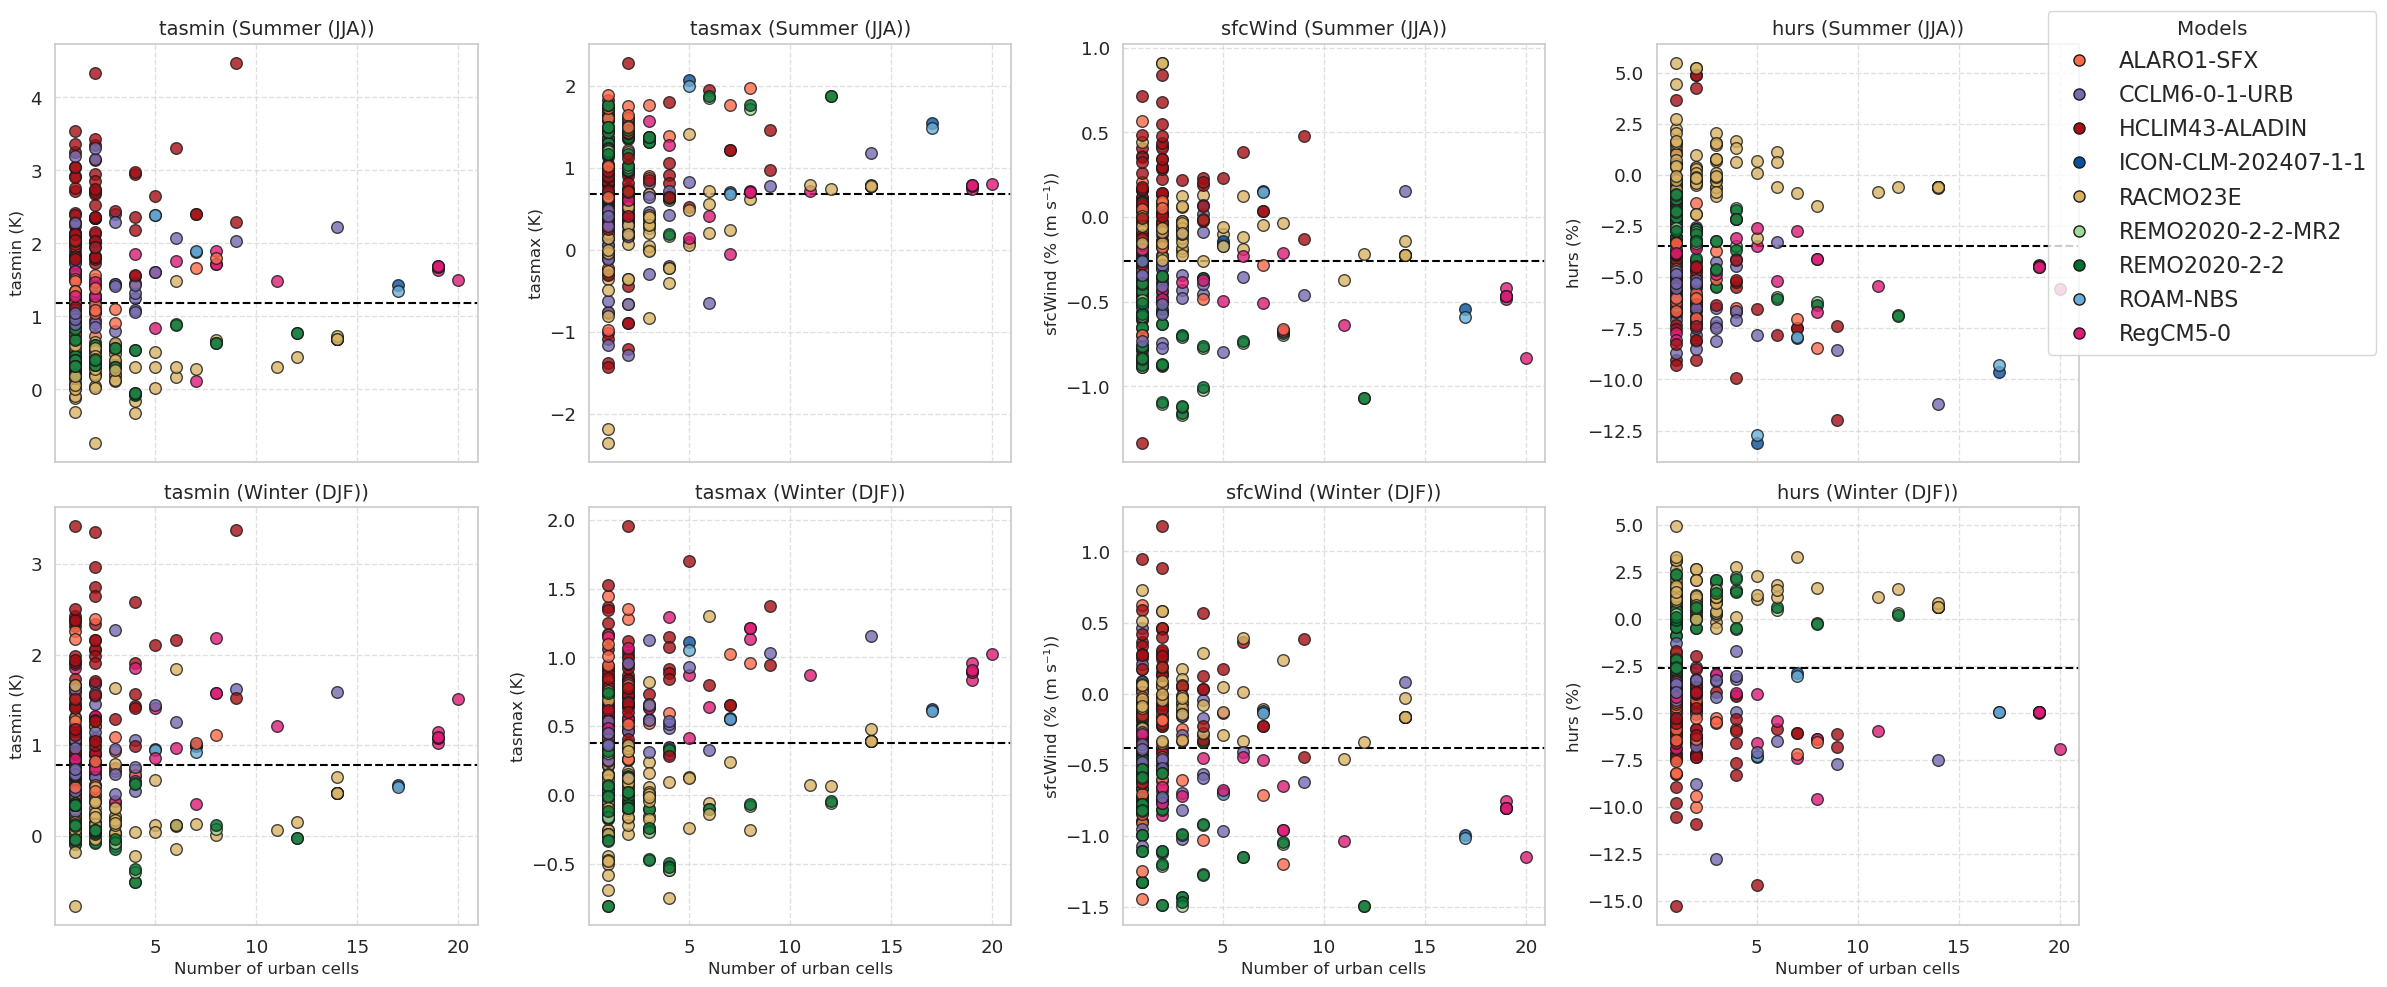

Combined scatter plot saved to: /mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/urban-evaluation/plots/summaries/CMIP6_Scatter_UrbanArea_AllVars_AllSeasons_1991-2020.png


In [31]:
# =============================================================================
# DATA CLEANING AND PREPARATION (df_box)
# =============================================================================
# Create a copy of the input data and convert to a Pandas DataFrame
df_box = pd.DataFrame(records).copy()

# Replace masked array values (which often come from NumPy masked arrays) with NaN
df_box["Value"] = df_box["Value"].apply(
    lambda x: np.nan if (isinstance(x, np.ma.MaskedArray) or np.ma.is_masked(x)) else x
)

# Remove rows where the main 'Value' is NaN (missing data)
df_box = df_box.dropna(subset=["Value"])

# Ensure 'City_Type' is a string and replace any resulting NaNs with 'Unknown'
df_box["City_Type"] = df_box["City_Type"].astype(str).replace("nan", "Unknown")



# =============================================================================
# GENERATE COMBINED SCATTER PLOTS (URBAN AREA ANALYSIS)
# =============================================================================
sns.set(style="whitegrid", font_scale=1.2)

seasons_to_plot = ["Summer (JJA)", "Winter (DJF)"]
variables = df_box["Variable"].unique()

n_rows = len(seasons_to_plot)
n_cols = len(variables)

# Create a figure and subplots with shared x-axis
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows), sharex=True)
if n_rows == 1:
    axes = [axes] # Ensure axes is iterable if only one row exists

for r, season in enumerate(seasons_to_plot):
    for c, variable in enumerate(variables):
        # Handle indexing for single-row and multi-row figures
        ax = axes[r][c] if n_rows > 1 else axes[c]
        
        # Filter the data for the current season and variable
        data_plot = df_box[(df_box["Season"] == season) & (df_box["Variable"] == variable)].copy()

        if data_plot.empty:
            ax.set_visible(False)
            continue

        # --- Scatter Plotting ---
        # Plot individual data points, colored by model
        for _, row in data_plot.iterrows():
            model_base = row["Model"].split("_v")[0] if "Model" in row else None
            color = model_color_map.get(model_base, "#444444")
            
            ax.scatter(
                row["urban_cells"],        # X-axis: Number of urban cells (proxy for area)
                row["Value"],              # Y-axis: Variable value
                s=70,                      # Marker size
                color=color,
                edgecolor='k',             # Black border for contrast
                alpha=0.8,
                zorder=3                   # Ensure points are on top
            )

        # --- Overall Mean Line ---
        # Plot the horizontal line representing the mean value across all models and cities
        mean_val = data_plot["Value"].mean()
        ax.axhline(mean_val, color="black", linestyle="--", lw=1.5, label="Mean")

        # --- Plot Labels and Aesthetics ---
        
        # Define units dictionary
        units = {
            "tasmin": "K",
            "tasmax": "K",
            "pr": "% (mm/day)",
            "sfcWind": "% (m s⁻¹)",
            "hurs": "%",
        }.get(variable, "")

        ax.set_title(f"{variable} ({season})", fontsize=14)
        ax.set_ylabel(f"{variable} ({units})", fontsize=12)
        
        # Set X-label only for the bottom row of subplots
        if r == n_rows - 1:
            ax.set_xlabel("Number of urban cells", fontsize=12)
        else:
            ax.set_xlabel("") # Remove x-label from upper rows
            
        ax.grid(True, linestyle="--", alpha=0.6)

# --- Manual Legend Creation (for CMIP6 Models) ---
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=m.split("_v")[0],
           markerfacecolor=model_color_map.get(m.split("_v")[0], "#444444"),
           markeredgecolor='k', markersize=8)
    for m in rcm_names
]
# Place the legend outside the plots
fig.legend(handles=legend_elements, loc='upper right', title="Models", fontsize=16)

# Adjust layout to accommodate the external legend
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()

# --- Save Figure ---
# Note: Assuming 'save_summary_path' and 'period' are defined
output_png_path = os.path.join(
    save_summary_path,
    f"CMIP6_Scatter_UrbanArea_AllVars_AllSeasons_{period.left}-{period.right}.png" # Updated filename for clarity
)
fig.savefig(output_png_path, dpi=300, bbox_inches="tight")
print(f"Combined scatter plot saved to: {output_png_path}")

### Boxplot with number of cells

/tmp/ipykernel_92670/563493637.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_92670/563493637.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_92670/563493637.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_92670/563493637.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_92670/563493637.py:181: UserWarning: 

Boxplot saved: /mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/urban-evaluation/plots/summaries/CMIP6_Boxplot_By_Urbancells_1991-2020.png
Boxplot saved: /mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/urban-evaluation/plots/summaries/CMIP6_Boxplot_By_Urbancells_1991-2020.pdf


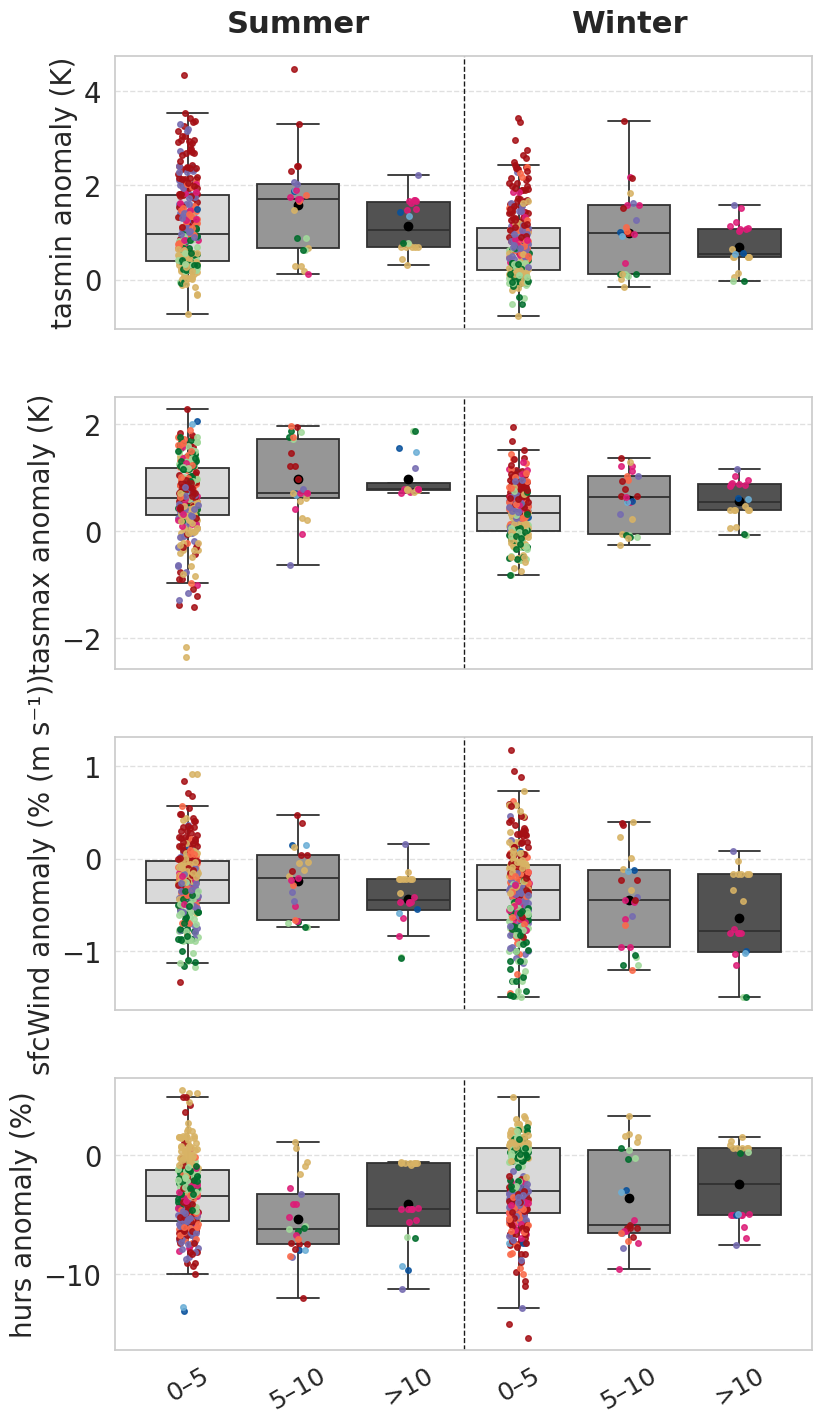

In [32]:
# =============================================================================
# DATA CLEANING AND MERGING
# =============================================================================
# Initialize the DataFrame and ensure a copy is made
df_box = pd.DataFrame(records).copy()
if df_box.empty:
    raise RuntimeError("The 'records' DataFrame is empty and cannot be processed.")

# Clean up any potential masked array values and replace them with NaN
df_box["Value"] = df_box["Value"].apply(
    lambda x: np.nan if (isinstance(x, np.ma.MaskedArray) or np.ma.is_masked(x)) else x
)
# Remove rows with NaN values in the primary data column
df_box = df_box.dropna(subset=["Value"])

# Extract the base model name (e.g., 'ALARO1-SFX')
df_box["Model_Base"] = df_box["Model"].str.split("_v").str[0]

# Merge the primary data with model metadata (e.g., color) from the external 'models_plot' DataFrame.
# This assumes 'models_plot' contains 'model', 'color', and 'urban' columns.
df_box = df_box.merge(
    models_plot[["model", "color"]], # Removed 'urban' as it's not used in this plot
    left_on="Model_Base", right_on="model", how="left"
).drop(columns=['model']) # Drop the redundant 'model' column after merge

# =============================================================================
# DEFINE URBAN CELL CLASSES (0–5, 5–10, >10)
# =============================================================================
def classify_cells(n):
    """Categorizes the number of urban cells into predefined bins."""
    if n <= 5:
        return "0–5"
    elif n <= 10:
        return "5–10"
    else:
        return ">10"

# Apply classification to the 'urban_cells' column
df_box["Urban_Class"] = df_box["urban_cells"].apply(classify_cells)

# Convert the classification column to a categorical type with explicit order
df_box["Urban_Class"] = pd.Categorical(
    df_box["Urban_Class"],
    categories=["0–5", "5–10", ">10"],
    ordered=True
)

# Combine Urban Class and Season for a unique x-axis category
df_box["Class_Season"] = (
    df_box["Urban_Class"].astype(str) + " " +
    df_box["Season"].str.replace(r"\s\(.+\)", "", regex=True)
)

# Define the explicit plotting order for the x-axis
urban_classes = ["0–5", "5–10", ">10"]
seasons = ["Summer", "Winter"]
type_season_order = [f"{u} {s}" for s in seasons for u in urban_classes]

# =============================================================================
# BOXPLOT COLORS DEFINITION
# =============================================================================
# Define a grayscale palette for the boxplot interiors/borders
urban_class_colors = {
    "0–5":  "#D9D9D9", # Light Gray
    "5–10": "#969696", # Medium Gray
    ">10":  "#525252"  # Dark Gray
}
# Create the ordered palette list for the seaborn function
class_season_palette = [
    urban_class_colors.get(cs.split()[0], "#0000FF") for cs in type_season_order
]

# =============================================================================
# PLOT SETTINGS AND INITIALIZATION
# =============================================================================
sns.set(style="whitegrid", font_scale=1.8)

variables = df_box["Variable"].unique()
n_vars = len(variables)
n_per_season = len(urban_classes)

# Figure dimensions calculated based on the number of categories and variables
fig_width = 3 * n_per_season
fig_height = 4.2 * n_vars

fig, axes = plt.subplots(
    nrows=n_vars,
    ncols=1,
    figsize=(fig_width, fig_height),
    sharex=True,
    gridspec_kw={"hspace": 0.25}
)
if n_vars == 1:
    axes = [axes] # Ensure axes is iterable for consistent loop indexing

# =============================================================================
# CREATE BOXPLOTS (FACETED BY VARIABLE)
# =============================================================================
for ax, variable in zip(axes, variables):
    data_plot = df_box[df_box["Variable"] == variable].copy()
    if data_plot.empty:
        continue

    # Generate the boxplot for the current variable
    sns.boxplot(
        data=data_plot,
        x="Class_Season",
        y="Value",
        order=type_season_order,
        showfliers=False, # Suppress outliers
        showmeans=True,  # Display mean marker
        meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"},
        palette=class_season_palette, # Use grayscale palette for boxes
        width=0.75,
        linewidth=1.3,
        ax=ax
    )

    # --- Overlay model-level points with jitter (FIXED TO USE model_color_map) ---
    for i, cat in enumerate(type_season_order):
        subset = data_plot[data_plot["Class_Season"] == cat]
        for _, row in subset.iterrows():
            # Retrieve model color using the base name and the global model_color_map
            model_base = row["Model_Base"]
            color = model_color_map.get(model_base, "#444444") # Default color if model not found
            
            # Apply random jitter for visual separation
            jitter = (random.random() - 0.5) * 0.18
            
            # Plot the individual model point
            ax.plot(i + jitter, row["Value"], 'o', color=color,
                    alpha=0.85, markersize=4, zorder=4)

    # Vertical separator between Summer and Winter categories
    ax.axvline(x=n_per_season - 0.5, color="k", linestyle="--", lw=1)

    # X-axis labels (only displaying the urban class name)
    ax.set_xticks(range(len(type_season_order)))
    ax.set_xticklabels(urban_classes * 2, fontsize=18, rotation=30)
    ax.set_xlabel("")
    ax.grid(True, axis="y", linestyle="--", alpha=0.6)

    # Y-axis label and units
    units = {
        "tasmin": "K",
        "tasmax": "K",
        "pr": "% (mm/day)",
        "sfcWind": "% (m s⁻¹)",
        "hurs": "%"
    }.get(variable, "")
    ax.set_ylabel(f"{variable} anomaly ({units})", fontsize=20)

# =============================================================================
# ADD SEASON LABELS (SUMMER/WINTER)
# =============================================================================
top_ax = axes[0]
ylim = top_ax.get_ylim()

# Calculate midpoints for season labels
summer_mid = (n_per_season - 1) / 2
winter_mid = n_per_season + (n_per_season - 1) / 2

# Place text labels above the plot area
top_ax.text(summer_mid, ylim[1] * 1.08, "Summer",
            ha="center", va="bottom", fontsize=22, fontweight="bold")
top_ax.text(winter_mid, ylim[1] * 1.08, "Winter",
            ha="center", va="bottom", fontsize=22, fontweight="bold")

# =============================================================================
# SAVE FIGURES
# =============================================================================
# Adjust layout to prevent clipping
plt.tight_layout(rect=[0, 0, 1, 1])

# Define output file paths
filename_base = f"CMIP6_Boxplot_By_Urbancells_{period.left}-{period.right}"
output_png_path = os.path.join(save_summary_path, f"{filename_base}.png")
output_pdf_path = os.path.join(save_summary_path, f"{filename_base}.pdf")

# Save the figure in both PNG and PDF formats
for path in [output_png_path, output_pdf_path]:
    fig.savefig(path, dpi=400, bbox_inches="tight")
    print(f"Boxplot saved: {path}")

plt.show()

## Analysis and Plots by Urban Scheme (Slab vs. UCM)

This section focuses on comparing the simulation results based on the type of Urban Scheme implemented in the Regional Climate Models (RCMs). The primary objective is to highlight differences and similarities between two key simplified urban representations: the Slab/Rock model and the Urban Canopy Model (UCM).

### Boxplot for each variable

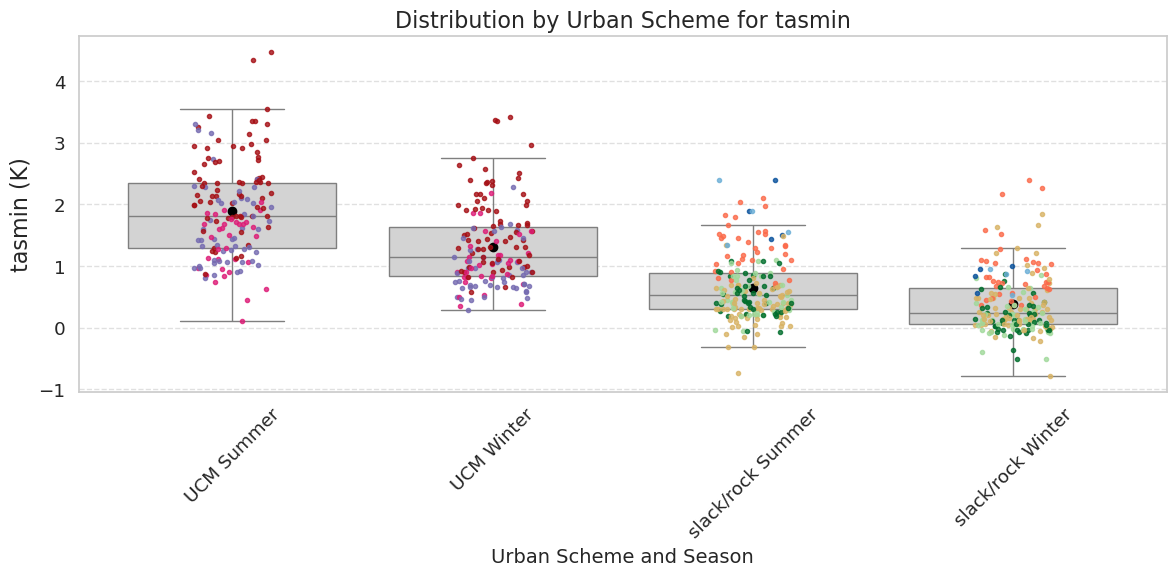

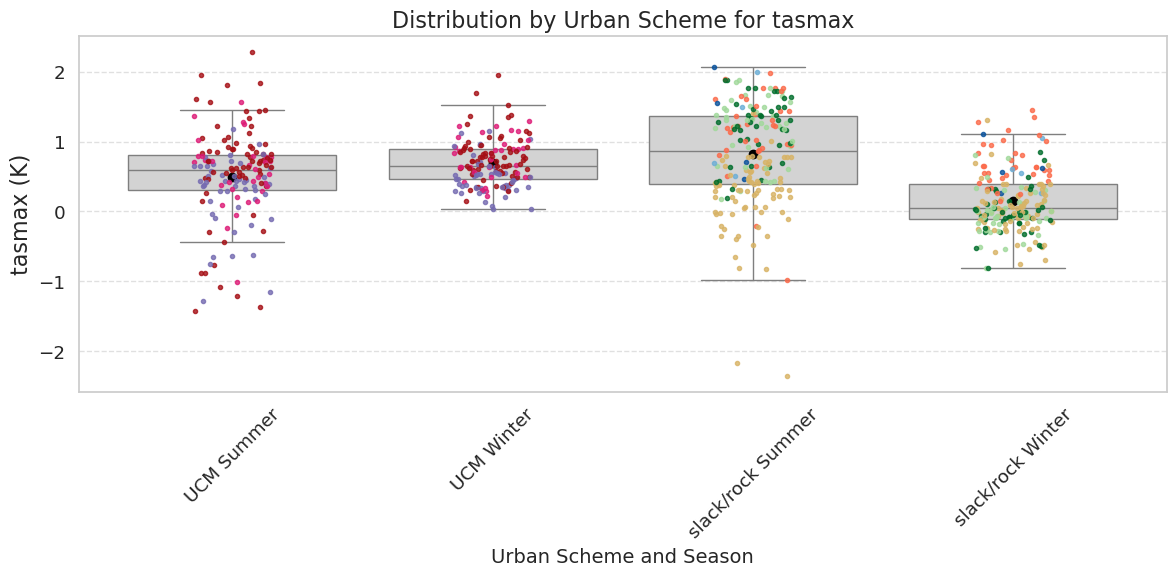

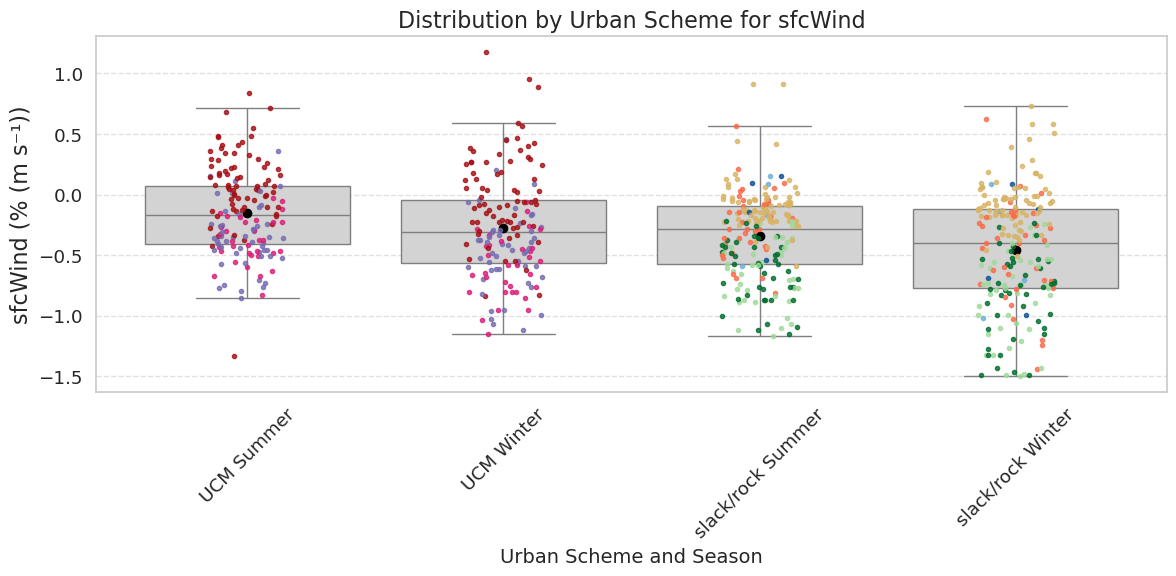

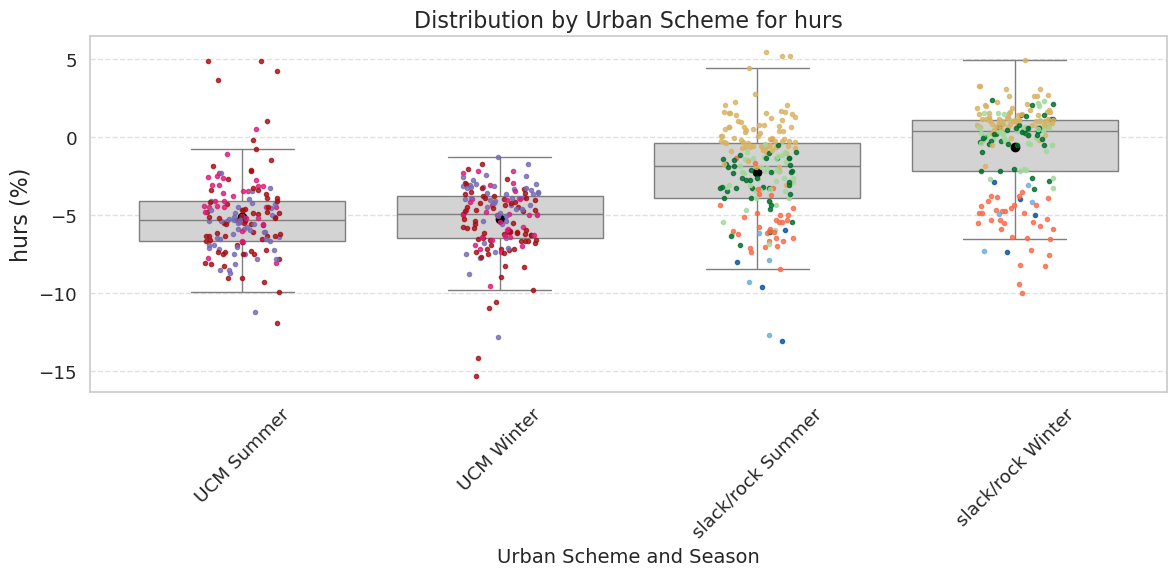

In [33]:
# =============================================================================
# MODEL METADATA: LOAD URBAN SCHEME INFORMATION
# =============================================================================
csv_path = "eurocordex_models_urban.csv"
# Load the model metadata file, including the 'urban' scheme variable
models_df = pd.read_csv(csv_path, sep=",", engine="python")

# Filter the DataFrame to retain only CMIP6 models
models_cmip6 = models_df[models_df["mip_era"] == "CMIP6"].copy()

# --- Color Cleaning Utility ---
def clean_color(c):
    """Ensures color string is a valid 7-character hex code, defaulting to black on fail."""
    if pd.isna(c):
        return "#000000"
    s = str(c).strip()
    if not s.startswith("#"):
        s = "#" + s
    # Validate hex format
    if len(s) != 7 or not all(ch in "0123456789ABCDEFabcdef#" for ch in s):
        return "#000000"
    return s

# Apply color cleaning to the model metadata
models_cmip6["color"] = models_cmip6["color"].apply(clean_color)

# =============================================================================
# DATA PREPARATION AND MERGING (df_box)
# =============================================================================
# Initialize the DataFrame from records
df_box = pd.DataFrame(records).copy()
if df_box.empty:
    raise RuntimeError("The 'records' DataFrame is empty. No data available for plotting.")

# Extract the base model name (without version suffix)
df_box["Model_Base"] = df_box["Model"].str.split("_v").str[0]

# Merge with model metadata to append 'color' and 'urban' scheme information
df_box = df_box.merge(
    models_cmip6[["model", "color", "urban"]],
    left_on="Model_Base", right_on="model", how="left"
).drop(columns=['model']) # Drop the redundant 'model' column after merge

# Handle missing urban schemes by classifying them as 'Unknown'
df_box["urban"] = df_box["urban"].fillna("Unknown")

# =============================================================================
# PLOT SETTINGS
# =============================================================================
sns.set(style="whitegrid", font_scale=1.2)

# =============================================================================
# BOXPLOTS FACETED BY URBAN SCHEME
# =============================================================================
# Iterate through each unique climate variable
for variable in df_box["Variable"].unique():
    plt.figure(figsize=(12, 6))
    data_plot = df_box[df_box["Variable"] == variable].copy()

    if data_plot.empty:
        print(f"No data available for {variable}. Skipping plot generation.")
        plt.close()
        continue

    # Combine Urban Scheme and Season for the x-axis categories
    data_plot["Urban_Season"] = (
        data_plot["urban"].astype(str) + " " +
        data_plot["Season"].str.replace(r"\s\(.+\)", "", regex=True)
    )

    # Define the order of categories (sorted alphabetically by default)
    order = sorted(data_plot["Urban_Season"].unique())

    # --- Boxplot Generation ---
    sns.boxplot(
        data=data_plot,
        x="Urban_Season",
        y="Value",
        order=order,
        showfliers=False,
        showmeans=True,
        meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"},
        color="lightgray", # Set a neutral color for the box bodies
    )

    # --- Overlay Individual Model Points (Colored by Model) ---
    for i, cat in enumerate(order):
        subset = data_plot[data_plot["Urban_Season"] == cat]
        
        # Overlay points for each model simulation
        for _, row in subset.iterrows():
            # Get the color using the Model_Base and the global model_color_map
            # Fallback to the 'color' column in df_box, which was populated during the merge
            model_base = row["Model_Base"]
            # Prioritize global map, fall back to merged column, then default gray
            color = model_color_map.get(model_base, row.get("color", "#444444")) 
            
            # Apply random jitter for visual separation
            jitter = (random.random() - 0.5) * 0.3
            
            # Plot the individual data point
            plt.plot(
                i + jitter, 
                row["Value"], 
                'o', 
                color=color, 
                alpha=0.8, 
                markersize=3, 
                zorder=4
            )

    # --- Labels and Formatting ---
    
    # Define units dictionary
    units = {
        "tasmin": "K",
        "tasmax": "K",
        "pr": "% (mm/day)",
        "sfcWind": "% (m s⁻¹)",
        "hurs": "%"
    }.get(variable, "")

    plt.title(f"Distribution by Urban Scheme for {variable}", fontsize=16) # Added title
    plt.ylabel(f"{variable} ({units})", fontsize=16)
    plt.xlabel("Urban Scheme and Season", fontsize=14)
    plt.grid(True, axis="y", linestyle="--", alpha=0.6)
    plt.xticks(rotation=45) # Rotate x-axis labels for readability
    plt.tight_layout()
    plt.show() # Added show plot command

### Final plot with all variables

/tmp/ipykernel_92670/1205208714.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_92670/1205208714.py:196: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels_simplified * 2, fontsize=20, rotation=30)
/tmp/ipykernel_92670/1205208714.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_92670/1205208714.py:196: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels_simplified * 2, fontsize=20, rotation=30)
/tmp/ipykernel_92670/1205208714.py:134: Futu

Boxplot saved: /mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/urban-evaluation/plots/summaries/CMIP6_Boxplot_By_UrbanScheme_AllVariables_1991-2020.png
Boxplot saved: /mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/urban-evaluation/plots/summaries/CMIP6_Boxplot_By_UrbanScheme_AllVariables_1991-2020.pdf


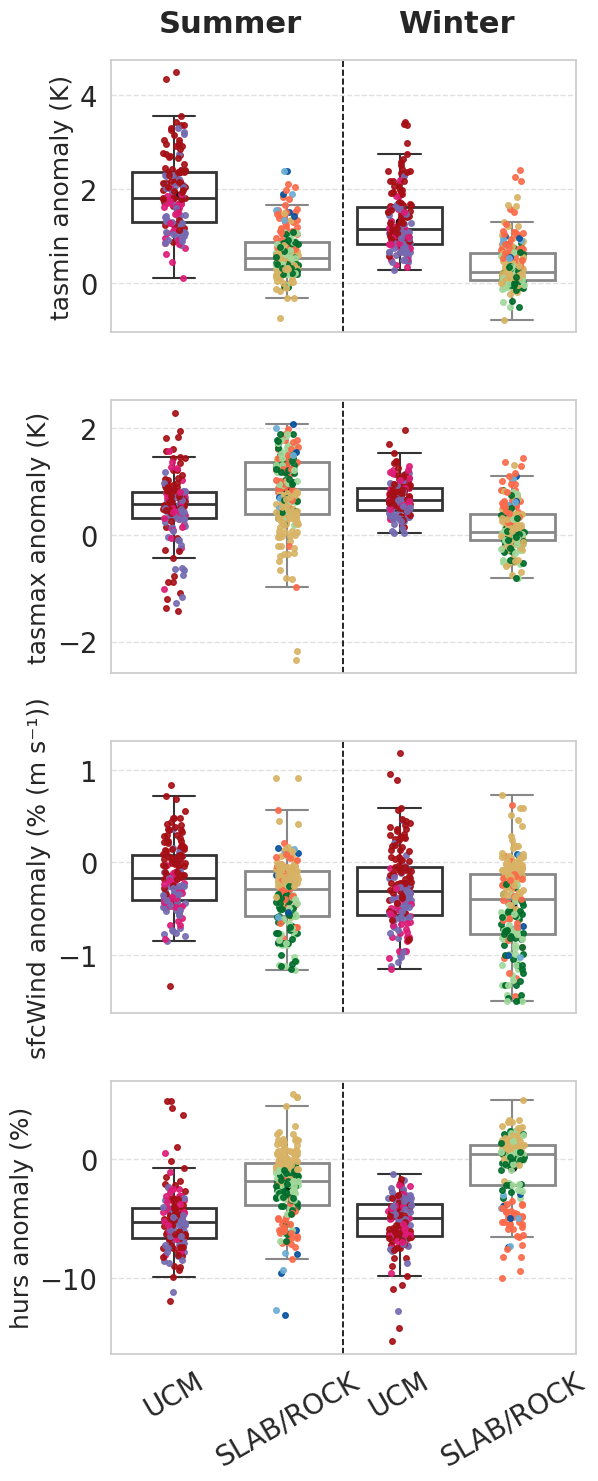

In [34]:
# =============================================================================
# LOAD EURO-CORDEX MODEL INFORMATION (URBAN SCHEMES)
# =============================================================================
csv_path = "eurocordex_models_urban.csv"
# Load the model metadata file, including the 'urban' scheme variable
models_df = pd.read_csv(csv_path, sep=",", engine="python")

# Filter the DataFrame to include only CMIP6 models
models_cmip6 = models_df[models_df["mip_era"] == "CMIP6"].copy()

# Function to ensure valid HEX color codes
def clean_color(c):
    """Ensures color string is a valid 7-character hex code, defaulting to black on fail."""
    if pd.isna(c):
        return "#000000"
    s = str(c).strip()
    if not s.startswith("#"):
        s = "#" + s
    if len(s) != 7 or not all(ch in "0123456789ABCDEFabcdef#" for ch in s):
        return "#000000"
    return s

# Apply color cleaning to the model metadata
models_cmip6["color"] = models_cmip6["color"].apply(clean_color)

# =============================================================================
# FILTER MODELS OF INTEREST (MATCHING AVAILABLE RCMs)
# =============================================================================
# Define the list of RCM names (for which data is available)
rcm_names = [
    'ALARO1-SFX_v1-r1', 'CCLM6-0-1-URB_v1-r1', 'HCLIM43-ALADIN_v1-r1',
    'ICON-CLM-202407-1-1_v1-r1', 'RACMO23E_v1-r1', 'REMO2020-2-2-MR2_v1-r1',
    'REMO2020-2-2_v1-r1', 'ROAM-NBS_v1-r1', 'RegCM5-0_v1-r1'
]
# Extract the base model names
rcm_base_names = [name.split("_v")[0] for name in rcm_names]
# Filter the CMIP6 metadata to include only the models corresponding to the RCMs
models_plot = models_cmip6[models_cmip6["model"].isin(rcm_base_names)].copy()


# =============================================================================
# DATA PREPARATION AND MERGING (df_box)
# =============================================================================
# Initialize the DataFrame from the input records
df_box = pd.DataFrame(records).copy()
if df_box.empty:
    raise RuntimeError("The 'records' DataFrame is empty. No data available for plotting.")

# Extract the base model name (without version suffix)
df_box["Model_Base"] = df_box["Model"].str.split("_v").str[0]

# Merge with 'models_plot' to retrieve the 'urban' scheme variable for each simulation
df_box = df_box.merge(
    models_plot[["model", "urban"]],
    left_on="Model_Base",
    right_on="model",
    how="left"
).drop(columns=['model']) # Remove redundant model name column

# Assign consistent model colors using the external 'model_color_map'
df_box["color"] = df_box["Model_Base"].map(model_color_map)

# Replace missing 'urban' schemes with 'Unknown'
df_box["urban"] = df_box["urban"].fillna("Unknown")

# --- Normalize Urban Scheme Names ---
def normalize_urban(u):
    """Normalizes urban scheme strings to simplified categories for plotting."""
    if isinstance(u, str):
        u = u.strip().upper()
        # Consolidate different names for the same scheme (e.g., SLAB/ROCK)
        if u in ["SLACK/ROCK", "SLAB/ROCK"]:
            return "SLAB/ROCK"
        elif u == "UCM":
            return "UCM"
    return "Unknown"

df_box["urban"] = df_box["urban"].apply(normalize_urban)

# Combine the normalized urban scheme and season for plot categorization
df_box["Urban_Season"] = (
    df_box["urban"].astype(str) + " " +
    df_box["Season"].str.replace(r"\s\(.+\)", "", regex=True)
)

# =============================================================================
# PLOT SETTINGS AND INITIALIZATION
# =============================================================================
sns.set(style="whitegrid", font_scale=1.8)

variables = df_box["Variable"].unique()
n_vars = len(variables)

# --- Define Order and Colors for Boxplots ---
x_labels_simplified = ["UCM", "SLAB/ROCK"]
seasons = ["Summer", "Winter"]
# Create the explicit order for the x-axis (e.g., 'UCM Summer', 'SLAB/ROCK Summer', 'UCM Winter', ...)
urban_order_simplified = [f"{u} {s}" for s in seasons for u in x_labels_simplified]

# Grayscale palette for box borders: UCM (darker) and SLAB/ROCK (lighter)
base_colors = {"UCM": "#333333", "SLAB/ROCK": "#888888"}
urban_scheme_colors_simplified = {f"{u} {s}": base_colors[u] for s in seasons for u in x_labels_simplified}

# Figure dimensions
fig_width = 3 * len(x_labels_simplified)
fig_height = 4.2 * n_vars
fig, axes = plt.subplots(
    nrows=n_vars, ncols=1, figsize=(fig_width, fig_height), sharex=True,
    gridspec_kw={"hspace": 0.25}
)
if n_vars == 1:
    axes = [axes] # Ensure axes is iterable

# =============================================================================
# CREATE BOXPLOTS (FACETED BY VARIABLE)
# =============================================================================
for ax, variable in zip(axes, variables):
    data_plot = df_box[df_box["Variable"] == variable].copy()
    if data_plot.empty:
        continue

    # Filter data to include only the simplified urban schemes being plotted
    data_plot = data_plot[data_plot["Urban_Season"].isin(urban_order_simplified)]

    # 1. Generate Boxplot (using white palette to control colors manually later)
    sns.boxplot(
        data=data_plot,
        x="Urban_Season",
        y="Value",
        order=urban_order_simplified,
        showfliers=False,
        showmeans=True,
        meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"},
        palette=["white"] * len(urban_order_simplified),
        width=0.75,
        linewidth=1.3,
        ax=ax
    )

    # 2. Manually set Box Edges (Grayscale) and Lines
    num_boxes = len(ax.patches)
    for i, patch in enumerate(ax.patches):
        ts = urban_order_simplified[i]
        # Set box interior to white and edge to the assigned grayscale
        patch.set_facecolor("white")
        patch.set_edgecolor(urban_scheme_colors_simplified[ts])
        patch.set_linewidth(2.0)
        patch.set_alpha(1.0)

    # Apply grayscale color to whiskers, caps, and median lines
    for box_i in range(num_boxes):
        ts = urban_order_simplified[box_i]
        color = urban_scheme_colors_simplified[ts]
        lines = ax.lines[6 * box_i: 6 * box_i + 6]
        for j, line in enumerate(lines):
            line.set_color(color)
            line.set_linewidth(2.0 if j == 4 else 1.5) # Median thicker

    # 3. Overlay individual model points with jitter (colored by model)
    for i, cat in enumerate(urban_order_simplified):
        subset = data_plot[data_plot["Urban_Season"] == cat]
        for _, row in subset.iterrows():
            # Retrieve color using the merged 'color' column (derived from model_color_map)
            color = row.get("color", "#444444") 
            
            # Apply random jitter
            jitter = (random.random() - 0.5) * 0.2
            
            # Plot the model point
            ax.plot(i + jitter, row["Value"], 'o', color=color, alpha=0.9, markersize=4, zorder=4)

    # 4. Vertical separator between Summer and Winter
    n_classes = len(x_labels_simplified)
    ax.axvline(n_classes - 0.5, color="black", linestyle="--", linewidth=1.2)

    # 5. Labels and Aesthetics
    # Y-labels and units
    units = {
        "tasmin": "K",
        "tasmax": "K",
        "pr": "% (mm/day)",
        "sfcWind": "% (m s⁻¹)",
        "hurs": "%"
    }.get(variable, "")
    ax.set_ylabel(f"{variable} anomaly ({units})", fontsize=18)

    # X labels (only urban scheme name, repeated for both seasons)
    ax.set_xticklabels(x_labels_simplified * 2, fontsize=20, rotation=30)
    ax.set_xlabel("") # Remove main x-axis label
    ax.grid(True, axis="y", linestyle="--", alpha=0.6)

# =============================================================================
# ADD SEASON LABELS (SUMMER/WINTER)
# =============================================================================
ax_top = axes[0]
x_mid_summer = (n_classes - 1) / 2
x_mid_winter = n_classes + (n_classes - 1) / 2
ylim = ax_top.get_ylim()
# Calculate text position slightly above the highest y-value
y_text = ylim[1] + (ylim[1] - ylim[0]) * 0.08 

# Place season labels
ax_top.text(x_mid_summer, y_text, "Summer", ha="center", va="bottom", fontsize=22, fontweight="bold")
ax_top.text(x_mid_winter, y_text, "Winter", ha="center", va="bottom", fontsize=22, fontweight="bold")

# Adjust layout to prevent clipping of text/labels
plt.tight_layout(rect=[0, 0, 1, 0.93])

# =============================================================================
# SAVE OUTPUT
# =============================================================================
# Define output file paths
filename_base = f"CMIP6_Boxplot_By_UrbanScheme_AllVariables_{period.left}-{period.right}"
output_png_path = os.path.join(save_summary_path, f"{filename_base}.png")
output_pdf_path = os.path.join(save_summary_path, f"{filename_base}.pdf")

# Save the figure in both formats
for path in [output_png_path, output_pdf_path]:
    fig.savefig(path, dpi=400, bbox_inches="tight")
    print(f"Boxplot saved: {path}")

plt.show()

## Analysis and Plots by AR6 Climate Region

This section details the analysis of climate projections based on the IPCC's AR6 (Sixth Assessment Report) reference regions, providing a standard geographical stratification for climate impact assessment.

### Classify each city

In [35]:
# =============================================================================
# LOAD AR6 (IPCC) REGIONS
# =============================================================================
# Access the defined AR6 regions (all regions) from regionmask
ar6 = regionmask.defined_regions.ar6.all

# Extract region properties
region_polygons = ar6.polygons
region_names = ar6.names
region_abbrevs = ar6.abbrevs

# Create a GeoDataFrame for the AR6 regions using the extracted data
gdf_ar6 = gpd.GeoDataFrame(
    {"AR6_Region": region_names, "AR6_Code": region_abbrevs},
    geometry=region_polygons,
    crs="EPSG:4326" # AR6 regions are defined in WGS84
)

# =============================================================================
# ENSURE CITY CENTROIDS AND COORDINATES
# =============================================================================
# Reproject 'gdf_europe' (containing urban geometries) to WGS84 (EPSG:4326) 
# if it is not already in a lat/lon CRS. This ensures compatibility for the spatial join.
if gdf_europe.crs is None or "4326" not in str(gdf_europe.crs):
    gdf_europe = gdf_europe.to_crs("EPSG:4326")

# Calculate the centroid for each urban area geometry
gdf_europe["centroid"] = gdf_europe.geometry.centroid
# Extract Longitude (x-coordinate) and Latitude (y-coordinate) from the centroids
gdf_europe["lon"] = gdf_europe["centroid"].x
gdf_europe["lat"] = gdf_europe["centroid"].y

# Create a new GeoDataFrame containing only the city centroids as Point geometries
gdf_points = gpd.GeoDataFrame(
    gdf_europe.copy(), # Create a copy of the city data
    geometry=gpd.points_from_xy(gdf_europe["lon"], gdf_europe["lat"]),
    crs="EPSG:4326"
)

# =============================================================================
# SPATIAL JOIN WITH AR6 REGIONS
# =============================================================================
# Perform a spatial join (left join) to find which AR6 region each city centroid falls within
# The 'predicate="within"' ensures a match only if the city centroid is inside an AR6 polygon.
gdf_joined = gpd.sjoin(gdf_points, gdf_ar6, how="left", predicate="within")

# Display columns after the join for debugging/verification
print("Columns after spatial join:\n", gdf_joined.columns)

# Extract the correct AR6 region columns and assign them back to the original 'gdf_europe'
# The spatial join appends a '_right' suffix if the column names ('AR6_Code', 'AR6_Region') 
# exist in both DataFrames. This logic handles the potential suffix difference.
if "AR6_Code_right" in gdf_joined.columns:
    gdf_europe["AR6_Code"] = gdf_joined["AR6_Code_right"]
    gdf_europe["AR6_Region"] = gdf_joined["AR6_Region_right"]
else:
    # Handle the case where the suffixes were not applied (e.g., if columns only existed in the right table)
    gdf_europe["AR6_Code"] = gdf_joined.get("AR6_Code", np.nan)
    gdf_europe["AR6_Region"] = gdf_joined.get("AR6_Region", np.nan)

# =============================================================================
# RESULT VERIFICATION
# =============================================================================
# Display the first few rows of the relevant columns to verify the successful join
print("\nVerification of AR6 Region Assignment:")
print(gdf_europe[["GC_UCN_MAI_2025", "lon", "lat", "AR6_Code", "AR6_Region"]].head())

Columns after spatial join:
 Index(['ID_UC_G0', 'GC_UCN_MAI_2025', 'GC_UCN_LIS_2025', 'GC_CNT_GAD_2025',
       'GC_CNT_UNN_2025', 'GC_UCA_KM2_2025', 'GC_POP_TOT_2025',
       'GC_DEV_WIG_2025', 'GC_DEV_USR_2025', 'GC_PLS_SCR_2025',
       'GC_UCB_YOB_2025', 'GC_UCB_YOD_2025', 'GC_UCM_CAP', 'geometry_char',
       'geometry_centroid', 'is_coastal', 'elevation', 'is_mountain',
       'is_inland', 'city_type', 'centroid', 'lon', 'lat', 'geometry',
       'index_right', 'AR6_Region', 'AR6_Code'],
      dtype='object')

Verification of AR6 Region Assignment:
           GC_UCN_MAI_2025        lon        lat AR6_Code           AR6_Region
68                   Turin   7.652705  45.068640      WCE  West&Central-Europe
73              Gothenburg  11.971914  57.705204      NEU             N.Europe
107                  Sofia  23.323590  42.682506      MED        Mediterranean
227                 Lisbon  -9.217014  38.760458      MED        Mediterranean
240  Rotterdam [The Hague]   4.362934  51.98

/tmp/ipykernel_92670/723278158.py:35: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_europe["centroid"] = gdf_europe.geometry.centroid


### Load the data

In [36]:
# Map city names (GC_UCN_MAI_2025) to AR6 Region Codes
city_to_region = dict(zip(gdf_europe["GC_UCN_MAI_2025"], gdf_europe["AR6_Code"]))
df_box = pd.DataFrame(records).copy()

### Plot the boxplot

/tmp/ipykernel_92670/1685116463.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(
/tmp/ipykernel_92670/1685116463.py:118: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([ts.split()[0] for ts in available_order], fontsize=20, rotation=30)
/tmp/ipykernel_92670/1685116463.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  box = sns.boxplot(
/tmp/ipykernel_92670/1685116463.py:118: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([ts.split()[0] for ts in available_order], fontsize=20, rotation=30

 Figure saved at: /mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/urban-evaluation/plots/summaries/CMIP6_Boxplot_AR6_AllVariables_1991-2020.png
 Figure saved at: /mnt/CORDEX_CMIP6_tmp/user_tmp/yquintana/urban-evaluation/plots/summaries/CMIP6_Boxplot_AR6_AllVariables_1991-2020.pdf


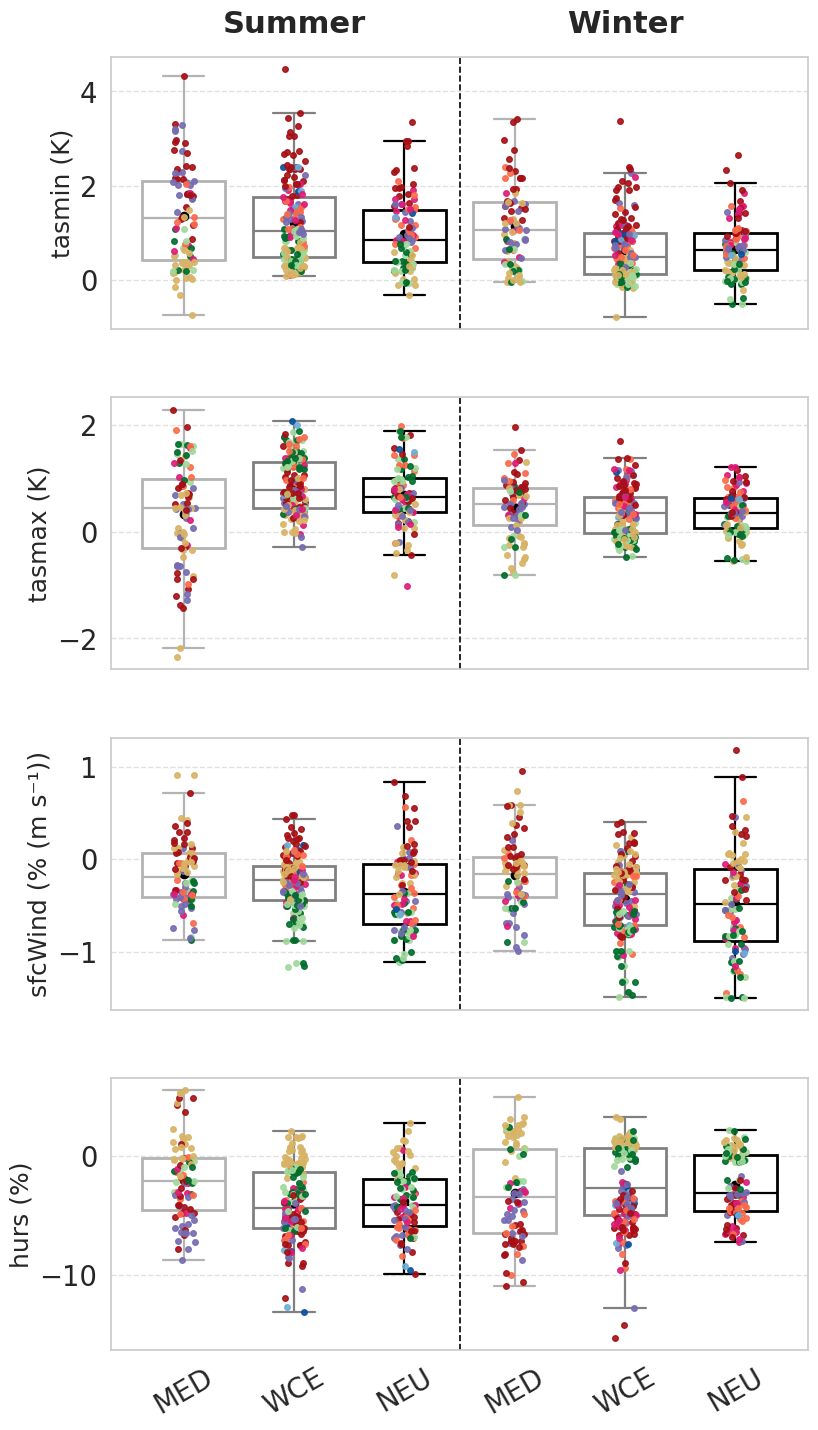

In [37]:
if not df_box.empty:
    # Add AR6 region code to the records DataFrame
    df_box["AR6_Code"] = df_box["City"].map(city_to_region)
    # Remove rows where AR6 Code is missing (cities outside the defined AR6 regions)
    df_box.dropna(subset=["AR6_Code"], inplace=True) 

    # Create Region + Season column (e.g., 'MED Summer')
    df_box["Region_Season"] = df_box["AR6_Code"] + " " + df_box["Season"].str.replace(r"\s\(.+\)", "", regex=True)

    sns.set(style="whitegrid", font_scale=1.8)

    # Define region order and grayscale palette
    gray_levels = ["0.7", "0.5", "0.0"] # Using strings for grayscale levels (light to dark gray)
    region_order = ["MED", "WCE", "NEU"] # Mediterranean, Western Central Europe, Northern Europe
    seasons = ["Summer", "Winter"]
    
    # Create the complete ordered list of categories (e.g., 'MED Summer', 'WCE Summer', ...)
    type_season_order = [f"{r} {s}" for s in seasons for r in region_order]
    region_color_map = {r: g for r, g in zip(region_order, gray_levels)}

    # Variables
    variables = df_box["Variable"].unique()
    n_vars = len(variables)
    
    # Calculate figure dimensions
    n_regions = len(region_order)
    fig_width = 3 * n_regions
    fig_height = 4.2 * n_vars

    fig, axes = plt.subplots(n_vars, 1, figsize=(fig_width, fig_height), sharex=True,
                             gridspec_kw={"hspace": 0.25})
    if n_vars == 1:
        axes = [axes] # Ensure axes is iterable

    for ax, variable in zip(axes, variables):
        data_plot = df_box[df_box["Variable"] == variable].copy()
        if data_plot.empty:
            continue

        # --- Filter order based on data availability (IMPORTANT FIX) ---
        # Only include categories present in the data for the current variable
        available_order = [ts for ts in type_season_order if ts in data_plot["Region_Season"].values]
        # Create a color list corresponding to the available_order
        palette_ordered_available = [region_color_map.get(ts.split()[0], "0.5") for ts in available_order]

        # 1. Generate Boxplot
        box = sns.boxplot(
            data=data_plot,
            x="Region_Season",
            y="Value",
            order=available_order, # Use the list of available categories
            ax=ax,
            showfliers=False,
            showmeans=True,
            meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"},
            palette=["white"] * len(available_order), # Use white palette
            width=0.75,
            linewidth=1.5
        )

        # 2. Color boxes and lines manually (FIXED iteration logic)
        for i, patch in enumerate(ax.patches):
            # Use the color map corresponding to the actually plotted box
            border_color = palette_ordered_available[i] 
            
            # Set box face/edge
            patch.set_facecolor("white")
            patch.set_edgecolor(border_color)
            patch.set_linewidth(2)

            # Manually color whiskers, caps, and median (6 lines per box)
            # Lines are indexed sequentially: 6 * i to 6 * i + 5
            for j in range(i * 6, i * 6 + 6):
                if j < len(ax.lines): # Safety check
                    ax.lines[j].set_color(border_color)
                    ax.lines[j].set_linewidth(1.6)

        # 3. Overlay model-level points with jitter (FIXED to use model_color_map and row data)
        for i, ts in enumerate(available_order):
            subset = data_plot[data_plot["Region_Season"] == ts]
            for _, row in subset.iterrows():
                # Extract the model base name
                model_base = row.get("Model", "").split("_v")[0]
                # Get the color from the established map
                color = model_color_map.get(model_base, "#444444")
                
                # Apply random jitter
                jitter = (random.random() - 0.5) * 0.2
                
                # Plot the individual model point
                ax.plot(i + jitter, row["Value"], 'o', color=color, alpha=0.9, markersize=4, zorder=4)

        # 4. Vertical line between Summer/Winter (based on the number of regions in the order)
        n_summer_regions = len([ts for ts in available_order if ts.split()[1] == "Summer"])
        ax.axvline(n_summer_regions - 0.5, color="black", linestyle="--", linewidth=1.2)

        # 5. Labels and grid
        units = {
            "tasmin": "K",
            "tasmax": "K",
            "pr": "% (mm/day)",
            "sfcWind": "% (m s⁻¹)",
            "hurs": "%"
        }.get(variable, "")
        
        ax.set_ylabel(f"{variable} ({units})", fontsize=18)
        ax.set_xlabel("")
        # Use only the AR6 code for the x-tick labels
        ax.set_xticklabels([ts.split()[0] for ts in available_order], fontsize=20, rotation=30)
        ax.grid(True, axis="y", linestyle="--", alpha=0.6)

    # 6. Summer/Winter top labels (use full 'region_order' count for positioning consistency)
    top_ax = axes[0]
    ylim = top_ax.get_ylim()
    
    # Calculate midpoints based on the total number of categories (N_regions for each season)
    n_total_categories = len(available_order)
    n_categories_per_season = n_total_categories / 2
    
    summer_mid = (0 + n_categories_per_season - 1) / 2
    winter_mid = summer_mid + n_categories_per_season

    top_ax.text(summer_mid, ylim[1] * 1.08, "Summer", ha="center", va="bottom",
                 fontsize=22, fontweight="bold")
    top_ax.text(winter_mid, ylim[1] * 1.08, "Winter", ha="center", va="bottom",
                 fontsize=22, fontweight="bold")

    # Save main figure
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    # Define output file paths
    filename_base = f"CMIP6_Boxplot_AR6_AllVariables_{period.left}-{period.right}"
    output_png_path = os.path.join(save_summary_path, f"{filename_base}.png")
    output_pdf_path = os.path.join(save_summary_path, f"{filename_base}.pdf")

    for path in [output_png_path, output_pdf_path]:
        fig.savefig(path, dpi=400, bbox_inches="tight")
        print(f" Figure saved at: {path}")

    plt.show()

else:
    print("df_box is empty; no data available for plotting.")

### Manually make the legend

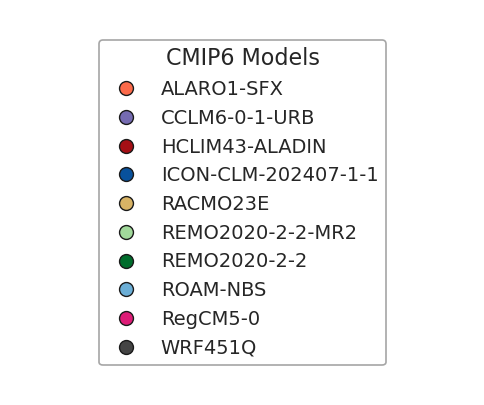

CMIP6 Model Color Mapping:
ALARO1-SFX -> #fb6a4a
CCLM6-0-1-URB -> #756bb1
HCLIM43-ALADIN -> #a50f15
ICON-CLM-202407-1-1 -> #08519c
RACMO23E -> #d8b365
REMO2020-2-2-MR2 -> #a1d99b
REMO2020-2-2 -> #006d2c
ROAM-NBS -> #6baed6
RegCM5-0 -> #dd1c77
WRF451Q -> #444444


In [41]:

# =============================================================================
# CREATE LEGEND ELEMENTS FOR EACH MODEL
# =============================================================================
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=m.split("_v")[0], # Use the base model name as the label
        # Retrieve the color from the map, defaulting to a dark gray if missing
        markerfacecolor=model_color_map.get(m.split("_v")[0], "#444444"), 
        markeredgecolor='k', # Black outline for visibility
        markersize=10
    )
    for m in rcm_names # Iterate over all RCMs of interest
]

# =============================================================================
# GENERATE AND DISPLAY STANDALONE LEGEND FIGURE
# =============================================================================
# Create a dedicated, temporary figure for the legend
fig_leg = plt.figure(figsize=(6, 5))
ax_leg = fig_leg.add_subplot(111)

# Turn off the axis display since this subplot only contains the legend
ax_leg.axis("off")

# Create the legend object
legend = ax_leg.legend(
    handles=legend_elements,
    title="CMIP6 Models",
    loc="center",
    fontsize=14,
    title_fontsize=16,
    ncol=1, # Single column layout
    frameon=True # Ensure the legend frame is visible
)

# Customize the appearance of the legend frame
frame = legend.get_frame()
frame.set_facecolor("white")
frame.set_alpha(0.7)
frame.set_edgecolor("gray")
frame.set_linewidth(1.2)

# Display the legend figure
plt.show()
plt.close(fig_leg) # Close the figure after displaying/saving

# =============================================================================
# PRINT MODEL-COLOR MAPPING TO CONSOLE
# =============================================================================
print("CMIP6 Model Color Mapping:")
for m in rcm_names:
    model_base = m.split('_v')[0]
    # Print the base model name and its assigned color code
    print(f"{model_base} -> {model_color_map.get(model_base, '#444444')}")

In [39]:
variable = 'tas'
rcm_names = ['ALARO1-SFX_v1-r1', 'CCLM6-0-1-URB_v1-r1', 'HCLIM43-ALADIN_v1-r1',
       'ICON-CLM-202407-1-1_v1-r1', 'RACMO23E_v1-r1',
       'REMO2020-2-2-MR2_v1-r1', 'REMO2020-2-2_v1-r1', 'ROAM-NBS_v1-r1',
       'RegCM5-0_v1-r1', 'WRF451Q_v1-r1']

AttributeError: 'pandas._libs.interval.Interval' object has no attribute 'start'

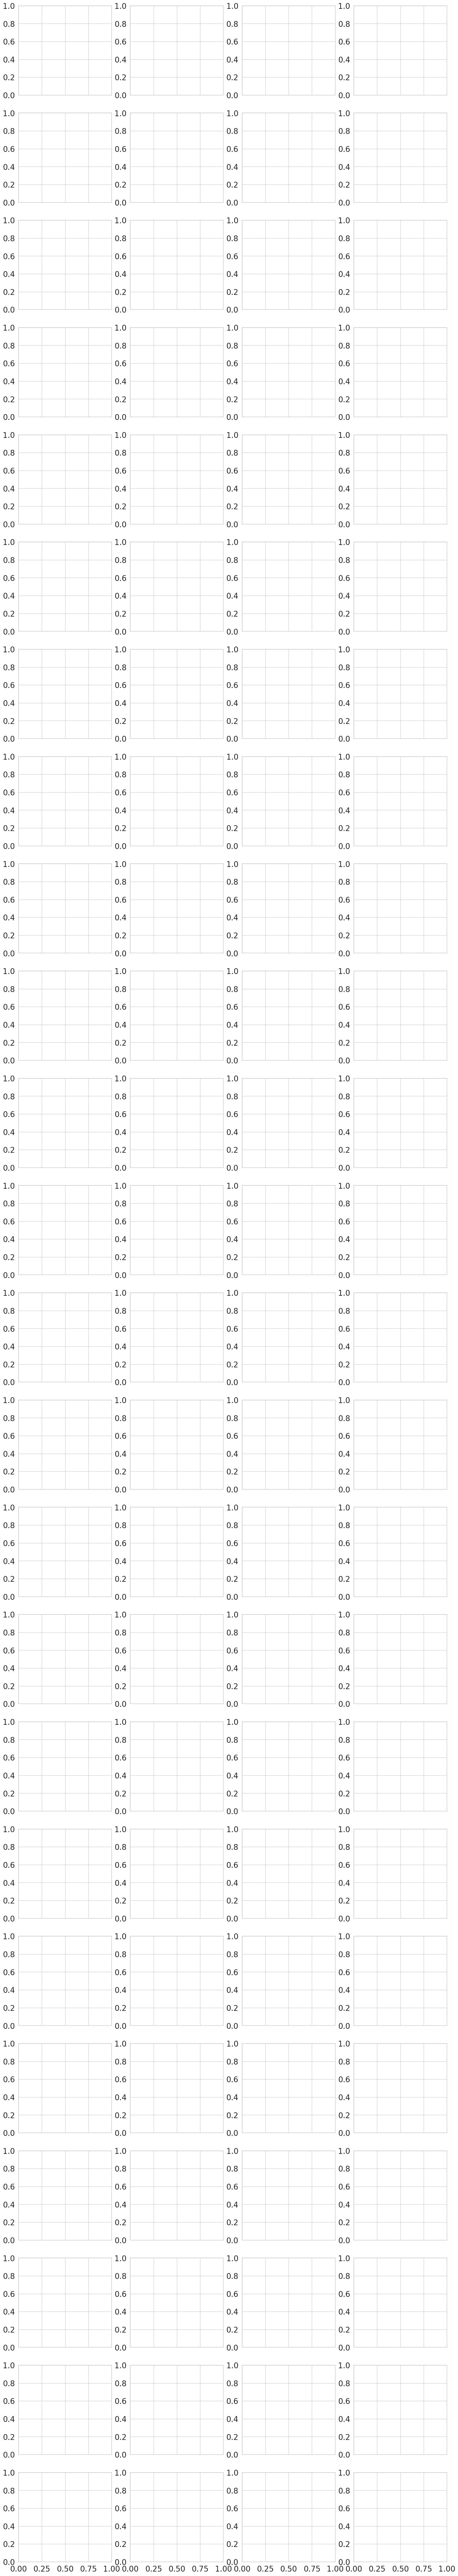

In [40]:
### Daily Cycle Plot ###
import os
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import math

# --- Initialize color palette ---
color_palette = plt.cm.tab10.colors
model_colors = {rcm: color_palette[i % len(color_palette)] for i, rcm in enumerate(rcm_names)}

# --- Create output directory for summaries ---
save_summary_path = os.path.join(save_figure_path, "summaries")
os.makedirs(save_summary_path, exist_ok=True)

# --- Layout configuration ---
ncols = 4
nplots = len([c for c in cities if c != "default"])
nrows = math.ceil(nplots / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 5 * nrows),
    sharex=True
)

# Flatten axes for easy iteration
axes = axes.flatten()

# --- Main loop: iterate through each city and model ---
plot_idx = 0
for city in cities:
    if city == "default":
        continue

    ax = axes[plot_idx]
    plot_idx += 1

    for rcm_name in rcm_names:
        # Define file paths
        output_nc_path = f"{save_figure_dataset}/CMIP6_{city}_Daily_cycle_{variable}_{rcm_name}_{period.start}-{period.stop}.nc"
        output_urmask_nc_path = f"{save_figure_dataset}/CMIP6_{city}_urmask_{rcm_name}.nc"

        # Skip if required files are missing
        if not (os.path.exists(output_nc_path) and os.path.exists(output_urmask_nc_path)):
            print(f"Skipping {city} - {rcm_name}: missing files.")
            continue
    
    try:
        # Load datasets
        ds_anomaly = xr.open_dataset(output_nc_path)[variable]
        urmask = xr.open_dataset(output_urmask_nc_path)
    
        # --- Align the spatial dimensions safely ---
        # Interpolate the mask to match ds_anomaly grid if necessary
        for dim in ["rlat", "lat", "y"]:
            if dim in ds_anomaly.dims and dim in urmask.dims:
                if ds_anomaly.sizes[dim] != urmask.sizes[dim]:
                    print(f"Resampling mask along {dim} for {city} - {rcm_name}")
                    urmask = urmask.interp({dim: ds_anomaly[dim]}, method="nearest")
    
        for dim in ["rlon", "lon", "x"]:
            if dim in ds_anomaly.dims and dim in urmask.dims:
                if ds_anomaly.sizes[dim] != urmask.sizes[dim]:
                    urmask = urmask.interp({dim: ds_anomaly[dim]}, method="nearest")
    
        # Now apply the urban mask
        is_urban = urmask['urmask'] == 1
        urban_anomaly = ds_anomaly.where(is_urban)
    
        # Compute spatial mean for urban area
        urban_mean = urban_anomaly.mean(
            dim=[d for d in ds_anomaly.dims if d not in ['hour']]
        ).compute()
    
        # Plot RCM results
        urban_mean.plot(
            ax=ax,
            color=model_colors[rcm_name],
            linewidth=2.5,
            label=rcm_name
        )
    
    except Exception as e:
        print(f"Error in {city} - {rcm_name}: {e}")
        continue


    # --- Plot observations if available ---
    output_obs_csv_path = f"{save_figure_dataset}/CMIP6_{city}_Daily_cycle_{variable}_OBS_{period.start}-{period.stop}.csv"
    if os.path.exists(output_obs_csv_path):
        obs_df = pd.read_csv(output_obs_csv_path)
        # Handle possible header/index issues
        if "hour" in obs_df.columns:
            x_axis = obs_df["hour"]
        else:
            x_axis = range(len(obs_df))
        ax.plot(
            x_axis,
            obs_df['urban_mean'],
            color='k',
            linestyle='--',
            marker='o',
            linewidth=3,
            label='Obs.',
            zorder=2000,
        )
    else:
        print(f"Missing observation file for {city}")

    # --- Axis formatting ---
    ax.set_ylabel(city, fontsize=16, rotation=90, labelpad=20, va='center')
    ax.yaxis.set_label_position("left")
    ax.grid(True, alpha=0.3)
    ax.set_title("")
    ax.set_xlabel("", fontsize=13)

    # Hours 0–23 or 0–24
    ax.set_xticks(range(0, 25, 3))
    ax.set_xlim(0, 24)
    ax.set_xticklabels([str(h) for h in range(0, 25, 3)], fontsize=12)

    # Dynamic y-limits (optional, you can adjust manually)
    #ax.set_ylim(-60, 50)

# --- Remove unused subplots ---
for j in range(plot_idx, len(axes)):
    fig.delaxes(axes[j])

# --- Legend, title, and save figure ---
handles, labels = axes[0].get_legend_handles_labels()

plt.tight_layout()
plt.subplots_adjust(top=0.85)

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    fontsize=14,
    bbox_to_anchor=(0.5, 0.95)
)

# Units per variable
units = {
    "tasmin": "K",
    "tasmax": "K",
    "pr": "% (mm/day)",
    "sfcWind": "% (m s⁻¹)"
}.get(variable, "")

fig.suptitle(
    f"{variable} Daily Cycle Anomaly ({units})",
    fontsize=18,
    y=0.9
)

# --- Save final figure ---
output_png_path = os.path.join(
    save_summary_path,
    f"CMIP6_AllCities_{variable}_DailyCycle_{period.start}-{period.stop}.png"
)
plt.savefig(output_png_path, dpi=300, bbox_inches="tight")
print(f" Figure saved to: {output_png_path}")
